In [1]:
import pandas as pd
import numpy as np

from math import sqrt
from pathlib import Path

import warnings
from enum import Enum

from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error


from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import ElasticNetCV, LassoCV, LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


from pandas.core.interchange import dataframe

import matplotlib.pyplot as plt
from variables import ALLCLINICAL06_VARS

### Store TXT files as CSV

In [2]:
input_path = Path("data/input")
output_path = Path("data/output")

In [4]:
for file_path in input_path.iterdir():
    file = pd.read_csv(file_path, sep="|")
    file.to_csv(file_path.with_suffix(".csv"), sep="|", index=False)

# Explore AllClinical06 dataset and define outcome parameters for summary_metrics_06

In [3]:
# Read file
all_clinical_06 = pd.read_csv(input_path / "AllClinical06.csv", sep="|")

## Aggregate x-ray dataset for KL grade

In [4]:
xr_df = pd.read_csv(input_path / "KXR_SQ_BU06.csv", sep="|")

# select Kellgren and Lawrence Score and take max grade per ID and side
xr_df_grade = xr_df[["ID", "SIDE", "V06XRKL"]]
xr_df_grade = xr_df_grade.groupby(["ID", "SIDE"])["V06XRKL"].max().reset_index()

# clean label format from SIDE and V06XRKL (e.g. "1: Right" --> "Right", "2: 2" -> "2")
xr_df_grade["SIDE"] = xr_df_grade["SIDE"].str.extract(r":\s*(\w+)")
xr_df_grade["V06XRKL"] = xr_df_grade["V06XRKL"].str.extract(r":\s*(\d+)").squeeze().astype(float).astype("Int64")

# Pivot from long to wide format -> one row per ID, separate columns for Left and Right
xr_df_wide = xr_df_grade.pivot(index="ID", columns="SIDE", values="V06XRKL")
xr_df_wide.columns = [f"V06XRKL_{col}" for col in xr_df_wide.columns]
xr_df_wide = xr_df_wide.reset_index()

"""
V06XRKL" defines Kellgren and Lawrence grade from 0-4

0 = none (definite absence of x-ray changes of osteoarthritis)
1 = doubtful (doubtful joint space narrowing and possible osteophytic lipping)
2 = minimal (definite osteophytes and possible joint space narrowing)
3 = moderate (moderate multiple osteophytes, definite narrowing of joint space, some sclerosis and possible deformity of bone ends)
4 = severe (large osteophytes, marked narrowing of joint space, severe sclerosis and definite deformity of bone ends)
"""

'\nV06XRKL" defines Kellgren and Lawrence grade from 0-4\n\n0 = none (definite absence of x-ray changes of osteoarthritis)\n1 = doubtful (doubtful joint space narrowing and possible osteophytic lipping)\n2 = minimal (definite osteophytes and possible joint space narrowing)\n3 = moderate (moderate multiple osteophytes, definite narrowing of joint space, some sclerosis and possible deformity of bone ends)\n4 = severe (large osteophytes, marked narrowing of joint space, severe sclerosis and definite deformity of bone ends)\n'

### Merge with clinical dataset

In [5]:
all_clinical_06_merged = xr_df_wide.merge(all_clinical_06, on="ID", how="inner")

## Aggregate MOAKS dataset for inflammation features

In [6]:
moaks_df = pd.read_csv(input_path / "kMRI_SQ_MOAKS_BICL06.csv", sep="|")

moaks_filtered = moaks_df[(moaks_df["V06MSYIC"] != ".: Missing Form/Incomplete Workbook") & (moaks_df["V06MEFFWK"] != ".: Missing Form/Incomplete Workbook")]

moaks_filtered_synovitis = moaks_df[moaks_df["V06MSYIC"] != ".: Missing Form/Incomplete Workbook"]
moaks_filtered_effusion = moaks_df[moaks_df["V06MEFFWK"] != ".: Missing Form/Incomplete Workbook"]

# check if the ID's overlap with Accelerometry ID's
Accelerometry06 = pd.read_csv(input_path / "Accelerometry06.csv", sep="|")
accelerometry_valid_participants_06 = Accelerometry06[Accelerometry06["V06APASTAT"] != "Not participating"]

patient_ids_with_complete_moaks = set(moaks_filtered["ID"].unique())
patient_ids_with_complete_synovitis = set(moaks_filtered_synovitis["ID"].unique())
patient_ids_with_valid_accelerometry = set(accelerometry_valid_participants_06["ID"].unique())
patient_ids_with_valid_accelerometry_effusion = set(moaks_filtered_effusion["ID"].unique())

overlap = patient_ids_with_complete_moaks & patient_ids_with_valid_accelerometry

print(f"\nPatienten mit vollständigen MOAKS-Daten:       {len(patient_ids_with_complete_moaks)}")
print(f"Patienten mit gültiger Accelerometrie:         {len(patient_ids_with_valid_accelerometry)}")
print(f"Überlappung (beide Datensätze):                {len(overlap)}")
print(f"Patienten mit gültigen Synovitis:              {len(patient_ids_with_complete_synovitis)}")
print(f"Patienten mit gültigen Synovitis:              {len(patient_ids_with_valid_accelerometry_effusion)}")



Patienten mit vollständigen MOAKS-Daten:       945
Patienten mit gültiger Accelerometrie:         2127
Überlappung (beide Datensätze):                527
Patienten mit gültigen Synovitis:              945
Patienten mit gültigen Synovitis:              946


### Merge moaks parameters with clinical dataset

In [7]:
# ── Remove duplicates (all NaN values, safe to drop)
moaks_dataframe_filtered = moaks_filtered.drop_duplicates(
    subset=["ID", "SIDE"],
    keep="first",
)

rows_per_patient = moaks_dataframe_filtered.groupby("ID").size()
print(rows_per_patient.value_counts())

# ── Strip whitespace from SIDE values before pivot
moaks_dataframe_filtered["SIDE"] = moaks_dataframe_filtered["SIDE"].str.strip()

# ── Pivot to wide format: one row per patient, one column per side
moaks_wide = moaks_dataframe_filtered.pivot(
    index="ID",
    columns="SIDE",
    values=["V06MSYIC", "V06MEFFWK"],
)

# Flatten column names using the numeric part of the SIDE string (e.g. "1: Right" -> "1")
moaks_wide.columns = [
    f"{variable}_{side.split(':')[0].strip()}"
    for variable, side in moaks_wide.columns
]
moaks_wide = moaks_wide.reset_index()

# Rename columns for readability
moaks_wide = moaks_wide.rename(columns={
    "V06MSYIC_1": "synovitis_right_knee",
    "V06MSYIC_2": "synovitis_left_knee",
    "V06MEFFWK_1": "effusion_right_knee",
    "V06MEFFWK_2": "effusion_left_knee",
})

# ── Parse labelled ordinal strings to numeric (e.g. '1: Mild' → 1)
for column_name in [
    "synovitis_right_knee",
    "synovitis_left_knee",
    "effusion_right_knee",
    "effusion_left_knee",
]:
    moaks_wide[column_name] = (
        moaks_wide[column_name]
        .str.extract(r"^(\d+)", expand=False)
        .pipe(pd.to_numeric, errors="coerce")
    )

# ── Worst-knee aggregation
moaks_wide["synovitis_worst_knee"] = moaks_wide[
    ["synovitis_right_knee", "synovitis_left_knee"]
].max(axis=1)

moaks_wide["effusion_worst_knee"] = moaks_wide[
    ["effusion_right_knee", "effusion_left_knee"]
].max(axis=1)

# ── Merge with AllClinical dataframe
all_clinical_06_merged = all_clinical_06_merged.merge(
    moaks_wide,
    on="ID",
    how="left",
)

print(f"Rows after merge:                    {len(all_clinical_06_merged)}")
print(f"Missing synovitis_worst_knee values: {all_clinical_06_merged['synovitis_worst_knee'].isna().sum()}")
print(f"Missing effusion_worst_knee values:  {all_clinical_06_merged['effusion_worst_knee'].isna().sum()}")

1    876
2     69
Name: count, dtype: int64
Rows after merge:                    3664
Missing synovitis_worst_knee values: 2741
Missing effusion_worst_knee values:  2741


### Exploring missing data

In [8]:
print("Missing columns:")
for col in all_clinical_06:
    missing = all_clinical_06[col].isna().sum()
    print(f"{col}: {missing}/{len(all_clinical_06[col])}")

Missing columns:
ID: 0/4796
VERSION: 0/4796
V06BLDRAW2: 4779/4796
V06ILLPWK2: 4778/4796
V06MULTST2: 4783/4796
V06URINOB1: 978/4796
V06PLAQHR1: 1037/4796
V06BLUPMN2: 4784/4796
V06HOURSP2: 4785/4796
V06VCOLL2: 4783/4796
V06ILLPWK1: 992/4796
V06MULTST1: 1004/4796
V06VEIN2: 4783/4796
V06URUPMN2: 4787/4796
V06VCOLL1: 1005/4796
V06HOURSP1: 1022/4796
V06HRSUC1: 1020/4796
V06URNCOLL: 540/4796
V06EXCESS2: 4783/4796
V06BLDRAW1: 996/4796
V06URINHR1: 1004/4796
V06HRSUC2: 4787/4796
V06QOVP1: 1005/4796
V06EXCESS1: 1005/4796
V06BLDCOLL: 540/4796
V06SEAQHR1: 1023/4796
V06VOID1: 550/4796
V06QOVP2: 4783/4796
V06VEIN1: 1004/4796
V06OTHVP1: 1004/4796
V06SEAQHR2: 4785/4796
V06OTHVP2: 4783/4796
V06URINHR2: 4787/4796
V06HEMAT1: 1005/4796
V06LEAKAG2: 4783/4796
V06BLSURD1: 4003/4796
V06BLDHRS1: 1021/4796
V06URSURD1: 3995/4796
V06URUPMN1: 1012/4796
V06HEMAT2: 4783/4796
V06LEAKAG1: 1005/4796
V06BLSURD2: 4793/4796
V06VOID2: 4659/4796
V06PLAQHR2: 4785/4796
V06URINOB2: 4665/4796
V06BLDHRS2: 4784/4796
V06URSURD2: 47

## Redundancy reduction for outcome parameter selection

In [8]:
pain_cols = [
        "ID",
        "V06KOOSKPR",  # Right knee: KOOS Pain Score, 0-100
        "V06WOMKPR",   # Right knee: WOMAC Pain Score, 0-20
        "V06CPSKR",  # ICOAP Right knee: Constant Pain Score, 0-100
        "V06IPSKR",  # ICOAP Right knee: Intermittent Pain Score, 0-100
        "V06ICPTSKR",  # ICOAP Right knee: Intermittent and Constant Pain Total Score, 0-100
        "V06P7RKFR",  # Right knee pain: how often, 0-4 (never, monthly, weekly, daily, always)
        "V06P7RKACV",  # Right knee pain: on average, past 7 days, rated on scale of 0-10
        "V06P7RKRCV",  # Right knee pain: severity, past 7 days, rated on scale of 0-10

        "V06KOOSKPL",  # Left knee: KOOS Pain Score (calc)
        "V06WOMKPL",  # Left knee: WOMAC Pain Score (calc)
        "V06CPSKL",  # ICOAP Left knee: Constant Pain Score (calc)
        "V06IPSKL",  # ICOAP Left knee: Intermittent Pain Score (calc)
        "V06ICPTSKL",  # ICOAP Left knee: Intermittent and Constant Pain Total Score (calc)
        "V06P7LKFR",  # Left knee pain: how often
        "V06P7LKACV",  # Left knee pain: on average, past 7 days, rated on scale of 0-10 (calc)
        "V06P7LKRCV",  # Left knee pain: severity, past 7 days, rated on scale of 0-10 (calc)

        "V06KGLRS",  # Considering all ways knee pain and arthritis affect you, how are you doing today? (0–10 scale)
    ]

sleep_cols = [
        "V06CESD11",  # FU SAQ:Q31k.CES-D: how often sleep was restless, past week 0-3
        "V06WPLKN3",  # FU INT:*Left knee pain: in bed, last 7 days, 0-4
        "V06WPRKN3",  # FU INT:*Right knee pain: in bed, last 7 days, 0-4
        "V06CPLKN2",  # FU INT:Q53r.ICOAP: Left knee constant pain: how much affected sleep, past 7 days
        "V06CPRKN2",  # FU INT:Q53d.ICOAP: Right knee constant pain: how much affected sleep, past 7 days
        "V06IPLKN3",  # FU INT:Q53y.ICOAP: Left knee intermittent pain: how much affected sleep, past 7 days
        "V06IPRKN3",  # FU INT:Q53k.ICOAP: Right knee intermittent pain: how much affected sleep, past 7 days
    ]

function_cols = [
        "V0620MPACE",  # 20-meter walk: pace (m/sec)
        "V06STEPST1",  # 20-meter walk: trial 1 number of steps
        "V06STEPST2",  # 20-meter walk: trial 2 number of steps
        "V06TIMET1",   # 20-meter walk: trial 1 time to complete (sec.hundredths/sec)
        "V06TIMET2",   # 20-meter walk: trial 2 time to complete (sec.hundredths/sec)
        "V06WLK20T1",  # 20-meter walk: trial 1 result
        "V06WLK20T2",  # 20-meter walk: trial 2 result
        "V06WLKAID",   # 20-meter walk: using walking aid such as cane

        "V06400EXCL",  # FU WBK:400-meter walk: reason excluded
        "V06400MCMP",  # FU WBK:400-meter walk: completion status
        "V06400MTIM",  # FU WBK:400-meter walk: total time at 400-m or at stop (sec)
        "V06400MTR",   # FU WBK:400-meter walk: total meters walked
        "V06400PAIN",  # FU WBK:400-meter walk: knee pain, which leg
        "V06CANEUSE",  # FU WBK:Q10.400-meter walk: use cane
        "V06COMP10",   # FU WBK:Q11.400-meter walk: complete full 10 laps
        "V06DISCOMF",  # FU WBK:Q12.400-meter walk: any discomfort
        "V06DKP400W",  # FU WBK:Q13.400-meter walk: knee pain during walk, don't know
        "V06HR135",    # FU WBK:Q9.400-meter walk: heart rate exceed 135 bpm during walk
        "V06HR400WK",  # FU WBK:Q8.400-meter walk: heart rate at 400-m or at stop
        "V06HRB4WLK",  # FU WBK:Q1.400-meter walk: heart rate before walk
        "V06LPN400W",  # FU WBK:Q13.400-meter walk: left knee pain during walk
        "V06LPWKPRV",  # FU WBK:Q13ii.400-meter walk: left knee pain prevent walking at usual pace
        "V06LPWKTYP",  # FU WBK:Q13i.400-meter walk: left knee pain mild, moderate or severe
        "V06NPN400W",  # FU WBK:Q13.400-meter walk: no knee pain during walk
        "V06NUMSTOP",  # FU WBK:Q4.400-meter walk: total number rest stops
        "V06OTH400W",  # FU WBK:Q12a.400-meter walk: type of discomfort, other
        "V06PN400W",   # FU WBK:Q12a.400-meter walk: type of discomfort, pain
        "V06REASW1",   # FU WBK:Q11a.400-meter walk: not able to complete 10 laps
        "V06REASW2",   # FU WBK:Q11a.400-meter walk: not able to complete 10 laps, began walk but could not complete
        "V06REASW3",   # FU WBK:Q11a.400-meter walk: not able to complete 10 laps, heart rate exceeded 135 bpm during walk and did not feel well
        "V06REASW4",  # FU WBK:Q11a.400-meter walk: not able to complete 10 laps, heart rate fell below 40 bpm during walk
        "V06REASW5",  # FU WBK:Q11a.400-meter walk: not able to complete 10 laps, reported felt too tired during walk
        "V06REASW6",  # FU WBK:Q11a.400-meter walk: not able to complete 10 laps, reported chest pain during walk
        "V06REASW7",  # FU WBK:Q11a.400-meter walk: not able to complete 10 laps, reported shortness of breath during walk
        "V06REASW8",  # FU WBK:Q11a.400-meter walk: not able to complete 10 laps, reported feeling faint during walk
        "V06REASW9",  # FU WBK:Q11a.400-meter walk: not able to complete 10 laps, reported knee pain during walk
        "V06REASW10",  # FU WBK:Q11a.400-meter walk: not able to complete 10 laps, reported hip pain during walk
        "V06REASW11",  # FU WBK:Q11a.400-meter walk: not able to complete 10 laps, reported calf pain during walk
        "V06REASW12",  # FU WBK:Q11a.400-meter walk: not able to complete 10 laps, reported back pain during walk
        "V06REASW13",  # FU WBK:Q11a.400-meter walk: not able to complete 10 laps, sat down during walk
        "V06REASW14",
        # FU WBK:Q11a.400-meter walk: not able to complete 10 laps, more than 15 minutes elapsed from start of test
        "V06REASW15",  # FU WBK:Q11a.400-meter walk: not able to complete 10 laps, refused
        "V06REASW16",  # FU WBK:Q11a.400-meter walk: not able to complete 10 laps, other
        "V06RESTT1",  # FU WBK:Q3a.400-meter walk: rest stop #1
        "V06RESTT2",  # FU WBK:Q3b.400-meter walk: rest stop #2
        "V06RESTT3",  # FU WBK:Q3c.400-meter walk: rest stop #3
        "V06RESTT4",  # FU WBK:Q3d.400-meter walk: rest stop #4
        "V06RESTT5",  # FU WBK:Q3e.400-meter walk: rest stop #5
        "V06RESTT6",  # FU WBK:Q3f.400-meter walk: rest stop #6
        "V06RESTT7",  # FU WBK:Q3g.400-meter walk: rest stop #7
        "V06RESTT8",  # FU WBK:Q3h.400-meter walk: rest stop #8
        "V06RESTT9",  # FU WBK:Q3i.400-meter walk: rest stop #9
        "V06RESTT10",  # FU WBK:Q3j.400-meter walk: rest stop #10
        "V06RFP400W",  # FU WBK:Q13.400-meter walk: knee pain during walk, refused
        "V06RPN400W",  # FU WBK:Q13.400-meter walk: right knee pain during walk
        "V06RPWKPRV",  # FU WBK:Q13ii.400-meter walk: right knee pain prevent from walking at usual pace
        "V06RPWKTYP",  # FU WBK:Q13i.400-meter walk: right knee pain mild, moderate or severe
        "V06SOB400W",  # FU WBK:Q12a.400-meter walk: type of discomfort, shortness of breath

        "V06SAFEWLK",  # FU WBK:Q12.400-meter walk eligibility: feel it would be safe to try to walk up and down hallway
        "V06SYSELG",
        # FU WBK:400-meter walk eligibility: meets new or old systolic blood pressure exclusion criterion (calc)
        "V06W20COMP",  # FU WBK:Q1.400-meter walk eligibility: able to complete trial 1 and trial 2 of the 20-meter walk
        "V06WALKER",  # FU WBK:Q6.400-meter walk eligibility: use walker or quad cane when walk
        "V06WHE400W",  # FU WBK:Q12a.400-meter walk: type of discomfort, wheezing/dyspnea
        "V06CALLDOC",
        # FU WBK:Q7.400-meter walk eligibility: had to see or call doctor for worsening angina (chest or heart pain) or worsening shortness of breath, past 3 months
        "V06DIASELG",
        # FU WBK:400-meter walk eligibility: meets new or old diastolic blood pressure exclusion criterion (calc)
        "V06HOSPSUR",
        # FU WBK:400-meter walk eligibility: meets new or old hospitalization/surgery exclusion criteria (calc)
        "V06HRELG",
        # FU WBK:400-meter walk eligibility: meets old or new heart rate exclusion criterion (calc) 18 Informat Label

        "V06CSTSGL",  # FU WBK:Single chair stand
        "V06CSTREP1",  # FU WBK:Repeated chair stands: trial 1
        "V06CSTIME1",  # WBK:Repeated chair stands: trial 1 time (sec.hundredths/sec) 12
        "V06CSTNUM1",
        # FU WBK:Repeated chair stands: trial 1, attempted, unable to complete: number completed without using arms
        "V06CSTIME2",  # 6.2 6.2 FU WBK:Repeated chair stands: trial 2 time (sec.hundredths/sec)
        "V06CSTNUM2",
        # FU WBK:Repeated chair stands: trial 2, attempted, unable to complete: number completed without using arms
        "V06CSTREP2",  # FU WBK:Repeated chair stands: trial 2
        "V06CS5",  # FU WBK:Repeated chair stands: able to complete 5 stands (calc)
        "V06CSPACE",  # FU WBK:Repeated chair stand: pace in stands/sec (calc)
    ]

depression_cols = [
        "V06CESD5",  # FU SAQ:Q31e.CES-D: how often had trouble keeping mind on what was doing, past week
        "V06CESD6",  # FU SAQ:Q31f.CES-D: how often felt depressed, past week
        "V06CESD7",  # FU SAQ:Q31g.CES-D: how often felt that everything did was an effort, past week
        "V06CESD10",  # FU SAQ:Q31j.CES-D: how often felt fearful, past week
        "V06CESD11",  # FU SAQ:Q31k.CES-D: how often sleep was restless, past week 9 Informat Label
        "V06CESD16",  # FU SAQ:Q31p.CES-D: how often enjoyed life, past week
        "V06CESD17",  # FU SAQ:Q31q.CES-D: how often had crying spells, past week
        "V06CESD20",  # FU SAQ:Q31t.CES-D: how often could not get going, past week
        "V06CESD",  # FU SAQ:CES-D: Center for Epidemiologic Studies Depression Scale (CES-D) Score
    ]

coping_strategies_cols = [
        "V06CSQCAT",  # FU INT:CSQ: Coping Strategies Questionnaire Score, Catastrophizing
        "V06CSQIGSN",  # FU INT:CSQ: Coping Strategies Questionnaire Score, Ignoring Sensations
        "V06CSQCSS",  # FU INT:CSQ: Coping Strategies Questionnaire Score, Coping Self-Statements
        "V06CSQDVAT",  # FU INT:CSQ: Coping Strategies Questionnaire Score, Diverting Attention
        "V06CSQRPS",  # FU INT:CSQ: Coping Strategies Questionnaire Score, Reinterpreting Pain Sensations
        "V06CSQPRHP",  # FU INT:CSQ: Coping Strategies Questionnaire Score, Praying or Hoping
        "V06CSQIBA",  # FU INT:CSQ: Coping Strategies Questionnaire Score, Increased Behavioral Activities
    ]

ADL_cols = [
         # ADL
        "V06ADL1",
        # FU INT:Q83.ADL: Any difficulty dressing, including putting on shoes and socks, because of health or memory problem
        "V06ADL2",  # FU INT:Q84.ADL: Any difficulty walking across a room because of health or memory problem
        "V06ADL3",  # FU INT:Q85.ADL: Ever use equipment or device such as cane, walker, or wheelchair when crossing a room
        "V06ADL4",  # FU INT:Q86.ADL: Does anyone ever help you get across a room
        "V06ADL5",
        # FU INT:Q87.ADL: Any difficulty bathing or showering because of health or memory problem 4 Informat Label
        "V06ADL6",  # FU INT:Q88.ADL: Any difficulty eating, such as cutting up food, because of health or memory problem
        "V06ADL7",  # FU INT:Q89.ADL: Any difficulty getting in or out of bed because of health or memory problem
        "V06ADL8",
        # FU INT:Q90.ADL: Ever use equipment or device such as cane, walker, or railing when getting in or out of bed
        "V06ADL9",  # FU INT:Q91.ADL: Does anyone every help you get in or out of bed
        "V06ADL10",
        # FU INT:Q92.ADL: Any difficulty using toilet, including getting up and down, because of health or memory problem 89 Variables in Creation Order Informat Label
        "V06ADL7A",
        # FU INT:Q89a.ADL: Use equipment or device such as cane, walker, or railing when getting in or out of bed
        "V06IADL2",  # FU INT:Q94.IADL: Any difficulty shopping for groceries because of health or memory problem
        "V06IADL2II",  # FU INT:Q94ii.IADL: does any help you shop for groceries 19

        # ADL / Late Life Disability (LLD)
        "V06LLD2A",  # FU SAQ:QD2a.LLDI: How often visit friends and family in their homes
        "V06LLD2B",  # FU SAQ:QD2b.LLDI: What extent feel limited in visiting friends and family in their homes
        "V06LLD4A",
        # FU SAQ:QD4a.LLDI: How often take care of the inside of your home (e.g., homemaking, laundry, housecleaning, minor household repairs)
        "V06LLD4B",
        # FU SAQ:QD4b.LLDI: What extent feel limited taking care of the inside of your home (e.g., homemaking, laundry, housecleaning, minor household repairs)
        "V06LLD5A",  # FU SAQ:QD5a.LLDI: How often work at volunteer job outside your home
        "V06LLD5B",  # FU SAQ:QD5b.LLDI: What extent feel limited working at volunteer job outside your home
        "V06LLD6A",
        # FU SAQ:QD6a.LLDI: How often take part in active recreation (e.g., bowling, golf, tennis, hiking, jogging, swimming)
        "V06LLD6B",  # FU SAQ:QD6b.LLDI: What extent feel limited in taking part in active recreation
        "V06LLD9A",  # FU SAQ:QD9a.LLDI: How often travel out of town for at least an overnight stay 28 Informat Label
        "V06LLD9B",  # FU SAQ:QD9b.LLDI: What extent feel limited in traveling out of town for at least an overnight stay
        "V06LLD10A",
        # FU SAQ:QD10a.LLDI: How often take part in regular fitness program (e.g., walking for exercise, stationary biking, weight lifting, exercise class)
        "V06LLD10B",
        # FU SAQ:QD10b.LLDI: What extent feel limited in taking part in regular fitness program (e.g., walk for exercise, stationary bike, weight lift, exercise class)
        "V06LLD11A",  # FU SAQ:QD11a.LLDI: How often invite people into your home for meal or entertainment
        "V06LLD11B",
        # FU SAQ:QD11b.LLDI: What extent feel limited in inviting people into your home for meal or entertainment
        "V06LLD12A",  # FU SAQ:QD12a.LLDI: How often go out with others to public places (e.g., restaurants, movies)
        "V06LLD12B",
        # FU SAQ:QD12b.LLDI: What extent feel limited in going out with others to public places (e.g., restaurants, movies)
        "V06LLD13A",
        # FU SAQ:QD13a.LLDI: How often take care of your own personal care needs (e.g., bathing, dressing, toileting)
        "V06LLD13B",
        # FU SAQ:QD13b.LLDI: What extent feel limited in taking care of your own personal care needs (e.g., bathing, dressing, toileting)
        "V06LLD14A",
        # FU SAQ:QD14a.LLDI: How often take part in organized social activities (e.g., clubs, card playing, senior center events, community or religious groups)
        "V06LLD14B",
        # FU SAQ:QD14a.LLDI: What extent feel limited taking part in organized social activities(e.g.,clubs,card playing,senior center events,community/religious groups) 88 Variables in Creation Order Informat Label
        "V06LLD15A",
        # FU SAQ:QD15a.LLDI: How often take care of local errands (e.g., shopping for food/personal items, going to bank, library, or dry cleaner)
        "V06LLD15B",
        # FU SAQ:QD15b.LLDI: What extent feel limited in taking care of local errands (e.g., shopping for food/personal items, going to bank, library, or dry cleaner)
        "V06LLD16A",
        # FU SAQ:QD16a.LLDI: How often prepare meals for yourself (e.g., planning, cooking, serving, cleaning up)
        "V06LLD16B",
        # FU SAQ:QD16b.LLDI: What extent feel limited in preparing meals for yourself (e.g., planning, cooking, serving, cleaning up)

        "V06LLDIFSP",
        # FU SAQ:LLDI: Late Life Disability Instrument, Frequency Dimension, Personal Role Domain Score (calc)
        "V06LLDIFSS",  # FU SAQ:LLDI: Late Life Disability Instrument, Frequency Dimension, Social Role Domain Score (calc)
        "V06LLDIFST",  # FU SAQ:LLDI: Late Life Disability Instrument, Frequency Dimension, Total Score (calc)
        "V06LLDILSI",
        # FU SAQ:LLDI: Late Life Disability Instrument, Limitation Dimension, Instrumental Role Domain Score (calc)
        "V06LLDILSM",
        # FU SAQ:LLDI: Late Life Disability Instrument, Limitation Dimension, Management Role Domain Score (calc)
        "V06LLDILST",  # FU SAQ:LLDI: Late Life Disability Instrument, Limitation Dimension, Total Score (calc)
    ]

function_koos_womac_cols = [
        # KOOS / WOMAC / Function
        "V06DIRKN1",  # FU INT:*Right knee difficulty: down stairs, last 7 days
        "V06DIRKN2",  # FU INT:*Right knee difficulty: up stairs, last 7 days
        "V06DIRKN3",  # FU INT:*Right knee difficulty: stand from sitting, last 7 days
        "V06DIRKN4",  # FU INT:*Right knee difficulty: standing, last 7 days
        "V06DIRKN5",  # FU INT:*Right knee difficulty: bending, last 7 days
        "V06DIRKN6",  # FU INT:*Right knee difficulty: walking, last 7 days
        "V06DIRKN7",  # FU INT:*Right knee difficulty: in car/out of car, last 7 days
        "V06DIRKN8",  # FU INT:*Right knee difficulty: shopping, last 7 days
        "V06DIRKN9",  # FU INT:*Right knee difficulty: socks on, last 7 days
        "V06DIRKN10", # FU INT:*Right knee difficulty: get out of bed, last 7 days
        "V06DIRKN11",  # FU INT:*Right knee difficulty: socks off, last 7 days
        "V06DIRKN12",  # FU INT:*Right knee difficulty: lying down, last 7 days
        "V06DIRKN13",  # FU INT:*Right knee difficulty: get in/out of bathtub, last 7 days
        "V06DIRKN14",  # FU INT:*Right knee difficulty: sitting, last 7 days
        "V06DIRKN15",  # FU INT:*Right knee difficulty: on/off toilet, last 7 days
        "V06DIRKN16",  # FU INT:*Right knee difficulty: heavy chores, last 7 days
        "V06DIRKN17",  # FU INT:*Right knee difficulty: light chores, last 7 days

        "V06DILKN1",  # FU INT:*Left knee difficulty: down stairs, last 7 days
        "V06DILKN2",  # FU INT:*Left knee difficulty: up stairs, last 7 days
        "V06DILKN3",  # FU INT:*Left knee difficulty: stand from sitting, last 7 days
        "V06DILKN4",  # FU INT:*Left knee difficulty: standing, last 7 days
        "V06DILKN5",  # FU INT:*Left knee difficulty: bending, last 7 days
        "V06DILKN6",  # FU INT:*Left knee difficulty: walking, last 7 days
        "V06DILKN7",  # FU INT:*Left knee difficulty: in car/out of car, last 7 days
        "V06DILKN8",  # FU INT:*Left knee difficulty: shopping, last 7 days
        "V06DILKN9",  # FU INT:*Left knee difficulty: socks on, last 7 days
        "V06DILKN10",  # FU INT:*Left knee difficulty: get out of bed, last 7 days
        "V06DILKN11",  # FU INT:*Left knee difficulty: socks off, last 7 days
        "V06DILKN12",  # FU INT:*Left knee difficulty: lying down, last 7 days
        "V06DILKN13",  # FU INT:*Left knee difficulty: get in/out of bathtub, last 7 days
        "V06DILKN14",  # FU INT:*Left knee difficulty: sitting, last 7 days
        "V06DILKN15",  # FU INT:*Left knee difficulty: on/off toilet, last 7 days
        "V06DILKN16",  # FU INT:*Left knee difficulty: heavy chores, last 7 days
        "V06DILKN17",  # FU INT:*Left knee difficulty: light chores, last 7 days

        "V06KOOSFX1",  # FU INT:*Q48a.Either knee difficulty: squatting, last 7 days
        "V06KOOSFX2",  # FU INT:*Q48b.Either knee difficulty: running, last 7 days
        "V06KOOSFX3",  # FU INT:*Q48c.Either knee difficulty: jumping, last 7 days
        "V06KOOSFX4",  # FU INT:*Q48d.Either knee difficulty: twisting/pivoting on injured knee, last 7 days
        "V06KOOSFX5",  # FU INT:*Q48e.Either knee difficulty: kneeling, last 7 days
    ]

pase_cols = [
        "V06PASE",  # FU INT:Physical Activity Scale for the Elderly (PASE) score (calc)
        "V06PASE1",  # FU INT:Leisure activities: sitting, past 7 days
        "V06PASE2",  # FU INT:Leisure activities: walking, past 7 days
        "V06PASE3",  # FU INT:Leisure activities: light sport/recreation, past 7 days
        "V06PASE4",  # FU INT:Leisure activities: moderate sport/recreation, past 7 days
        "V06PASE5",  # FU INT:Leisure activities: strenuous sport/recreation, past 7 days
        "V06PASE6",  # FU INT:Leisure activities: muscle strength/endurance, past 7 days
        "V06PASE1HR",  # FU INT:Leisure activities: sitting, hours per day, past 7 days
        "V06PASE2HR",  # FU INT:Leisure activities: walking, hours per day, past 7 days
        "V06PASE3HR",  # FU INT:Leisure activities: light sport/recreation, hours per day, past 7 days
        "V06PASE4HR",  # FU INT:Leisure activities: moderate sport/recreation, hours per day, past 7 days
        "V06PASE5HR",  # FU INT:Leisure activities: strenuous sport/recreation, hours per day, past 7 days
        "V06PASE6HR",  # FU INT:Leisure activities: muscle strength/endurance, hours per day, past 7 days 34
        "V06HOUACT1",  # FU INT:Household activities: light housework, past 7 days
        "V06HOUACT2",  # FU INT:Household activities: heavy housework, past 7 days
        "V06HOUACT3",  # FU INT:Household activities: home repairs, past 7 days
        "V06HOUACT4",  # FU INT:Household activities: lawn work/yard care, past 7 days
        "V06HOUACT5",  # FU INT:Household activities: outdoor gardening, past 7 days
        "V06HOUACT6",  # FU INT:Household activities: caring for another person, past 7 days
    ]

replacement_cols = [
         "V06HRS12",
        # FU INT:Q56.Had hip replacement surgery where all or part of joint was replaced, since last visit about 12 months ago
        "V06SREPHR", # FU INT:Ever have hip replacement surgery where all or part of joint was replaced, self-report (calc)
    ]

### Redundancy function

In [9]:
def compute_spearman_correlation_matrix(
    dataframe: pd.DataFrame,
    columns: list[str],
) -> pd.DataFrame:
    """
    Compute a pairwise Spearman correlation matrix for the given columns.

    Missing values are handled pairwise. Columns with fewer than 10
    joint observations are set to NaN. Constant input pairs are silently
    set to NaN rather than raising a ConstantInputWarning.

    :param dataframe: DataFrame containing the columns.
    :param columns: List of column names to include.
    :returns: Symmetric DataFrame of Spearman correlation coefficients.
    """
    import warnings
    from scipy.stats import ConstantInputWarning

    valid_columns = [
        column for column in columns
        if column in dataframe.columns
        and pd.api.types.is_numeric_dtype(dataframe[column])
        and dataframe[column].nunique() > 1
    ]

    number_of_columns = len(valid_columns)
    correlation_matrix = pd.DataFrame(
        data=np.eye(number_of_columns),
        index=valid_columns,
        columns=valid_columns,
    )

    for index_i, column_i in enumerate(valid_columns):
        for index_j in range(index_i + 1, number_of_columns):
            column_j = valid_columns[index_j]
            joint_observations = dataframe[[column_i, column_j]].dropna()

            if len(joint_observations) < 10:
                correlation_matrix.loc[column_i, column_j] = np.nan
                correlation_matrix.loc[column_j, column_i] = np.nan
                continue

            with warnings.catch_warnings():
                warnings.simplefilter("ignore", ConstantInputWarning)
                rho, _ = stats.spearmanr(
                    joint_observations[column_i],
                    joint_observations[column_j],
                )

            if np.isnan(rho):
                correlation_matrix.loc[column_i, column_j] = np.nan
                correlation_matrix.loc[column_j, column_i] = np.nan
            else:
                correlation_matrix.loc[column_i, column_j] = rho
                correlation_matrix.loc[column_j, column_i] = rho

    return correlation_matrix

def print_redundant_pairs(
    correlation_matrix: pd.DataFrame,
    redundancy_threshold: float = 0.85,
) -> pd.DataFrame:
    """
    Print and return all variable pairs exceeding the redundancy threshold.

    :param correlation_matrix: Pairwise Spearman correlation matrix.
    :param redundancy_threshold: Absolute correlation above which two
        variables are considered redundant. Defaults to 0.85.
    :returns: DataFrame of redundant pairs sorted by correlation strength,
        or an empty DataFrame if no redundant pairs are found.
    """
    variables = list(correlation_matrix.columns)
    redundant_pairs = []

    for index_i, variable_i in enumerate(variables):
        for index_j in range(index_i + 1, len(variables)):
            variable_j = variables[index_j]
            rho = correlation_matrix.loc[variable_i, variable_j]

            if pd.isna(rho):
                continue

            if abs(rho) >= redundancy_threshold:
                redundant_pairs.append({
                    "variable_a": variable_i,
                    "variable_b": variable_j,
                    "spearman_rho": round(rho, 3),
                })

    print(f"\nRedundant pairs (|ρ| ≥ {redundancy_threshold})")
    print(f"{'Variable A':<20} {'Variable B':<20} {'ρ':>6}")
    print("-" * 50)

    # --- early return BEFORE attempting sort ---
    if not redundant_pairs:
        print("No redundant pairs found — all variables are sufficiently distinct.")
        return pd.DataFrame(columns=["variable_a", "variable_b", "spearman_rho"])

    pairs_dataframe = pd.DataFrame(redundant_pairs).sort_values(
        by="spearman_rho",
        ascending=False,
    ).reset_index(drop=True)

    for _, row in pairs_dataframe.iterrows():
        print(
            f"{row['variable_a']:<20} "
            f"{row['variable_b']:<20} "
            f"{row['spearman_rho']:>6.3f}"
        )
    print(f"\n{len(pairs_dataframe)} redundant pairs found.")

    return pairs_dataframe

### Assess redundancy among pain variables

In [12]:
correlation_matrix = compute_spearman_correlation_matrix(
    dataframe=all_clinical_06_merged,
    columns=pain_cols,
)

redundant_pairs = print_redundant_pairs(
    correlation_matrix=correlation_matrix,
    redundancy_threshold=0.85,
)


Redundant pairs (|ρ| ≥ 0.85)
Variable A           Variable B                ρ
--------------------------------------------------
V06IPSKR             V06ICPTSKR            0.924
V06IPSKL             V06ICPTSKL            0.918
V06P7LKACV           V06P7LKRCV            0.894
V06P7RKACV           V06P7RKRCV            0.884
V06P7LKFR            V06P7LKRCV            0.868
V06WOMKPR            V06P7RKRCV            0.863
V06WOMKPL            V06P7LKRCV            0.860
V06ICPTSKL           V06P7LKRCV            0.860
V06KOOSKPR           V06P7RKRCV           -0.893
V06KOOSKPL           V06P7LKRCV           -0.905
V06KOOSKPR           V06P7RKFR            -0.916
V06KOOSKPL           V06WOMKPL            -0.930
V06KOOSKPL           V06P7LKFR            -0.930
V06KOOSKPR           V06WOMKPR            -0.938

14 redundant pairs found.


### Assess redundancy among sleep variables

In [17]:
correlation_matrix = compute_spearman_correlation_matrix(
    dataframe=all_clinical_06_merged,
    columns=sleep_cols,
)

redundant_pairs = print_redundant_pairs(
    correlation_matrix=correlation_matrix,
    redundancy_threshold=0.85,
)


Redundant pairs (|ρ| ≥ 0.85)
Variable A           Variable B                ρ
--------------------------------------------------
V06CPRKN2            V06IPRKN3             0.932
V06CPLKN2            V06IPLKN3             0.891

2 redundant pairs found.


### Assess redundancy among function variables

In [47]:
correlation_matrix = compute_spearman_correlation_matrix(
    dataframe=all_clinical_06_merged,
    columns= function_cols,
)

redundant_pairs = print_redundant_pairs(
    correlation_matrix=correlation_matrix,
    redundancy_threshold=0.85,
)


Redundant pairs (|ρ| ≥ 0.85)
Variable A           Variable B                ρ
--------------------------------------------------
V06400MTR            V06COMP10             1.000
V06STEPST1           V06STEPST2            0.966
V06TIMET1            V06TIMET2             0.958
V06CSTIME1           V06CSTIME2            0.950
V06400EXCL           V06400MCMP            0.900
V06400EXCL           V06COMP10            -0.880
V06WLK20T1           V06W20COMP           -0.966
V06CSTIME1           V06CSPACE            -0.966
V06400MCMP           V06400MTR            -0.978
V0620MPACE           V06TIMET1            -0.987
V0620MPACE           V06TIMET2            -0.991
V06CSTREP1           V06CS5               -0.992
V06400MCMP           V06COMP10            -0.994
V06CSTIME2           V06CSPACE            -0.994
V06WLK20T2           V06W20COMP           -1.000

15 redundant pairs found.


### Assess redundancy among depression variables

In [49]:
correlation_matrix = compute_spearman_correlation_matrix(
    dataframe=all_clinical_06_merged,
    columns= depression_cols,
)

redundant_pairs = print_redundant_pairs(
    correlation_matrix=correlation_matrix,
    redundancy_threshold=0.85,
)


Redundant pairs (|ρ| ≥ 0.85)
Variable A           Variable B                ρ
--------------------------------------------------
No redundant pairs found — all variables are sufficiently distinct.


### Assess redundancy among coping strategies variables

In [50]:
correlation_matrix = compute_spearman_correlation_matrix(
    dataframe=all_clinical_06_merged,
    columns= coping_strategies_cols,
)

redundant_pairs = print_redundant_pairs(
    correlation_matrix=correlation_matrix,
    redundancy_threshold=0.85,
)


Redundant pairs (|ρ| ≥ 0.85)
Variable A           Variable B                ρ
--------------------------------------------------
No redundant pairs found — all variables are sufficiently distinct.


### Assess redundancy among ADL variables

In [51]:
correlation_matrix = compute_spearman_correlation_matrix(
    dataframe=all_clinical_06_merged,
    columns= ADL_cols,
)

redundant_pairs = print_redundant_pairs(
    correlation_matrix=correlation_matrix,
    redundancy_threshold=0.85,
)


Redundant pairs (|ρ| ≥ 0.85)
Variable A           Variable B                ρ
--------------------------------------------------
V06LLDILSI           V06LLDILST            0.991
V06LLDIFSS           V06LLDIFST            0.918
V06LLD11B            V06LLDILSM            0.903

3 redundant pairs found.


### Assess redundancy among function KOOS/WOMAC variables


In [56]:
correlation_matrix = compute_spearman_correlation_matrix(
    dataframe=all_clinical_06_merged,
    columns= function_koos_womac_cols,
)

redundant_pairs = print_redundant_pairs(
    correlation_matrix=correlation_matrix,
    redundancy_threshold=0.85,
)


Redundant pairs (|ρ| ≥ 0.85)
Variable A           Variable B                ρ
--------------------------------------------------
V06DILKN9            V06DILKN11            0.914
V06KOOSFX2           V06KOOSFX3            0.894
V06DIRKN9            V06DIRKN11            0.856

3 redundant pairs found.


### Assess redundancy among pase variables


In [58]:
correlation_matrix = compute_spearman_correlation_matrix(
    dataframe=all_clinical_06_merged,
    columns= pase_cols,
)

redundant_pairs = print_redundant_pairs(
    correlation_matrix=correlation_matrix,
    redundancy_threshold=0.85,
)


Redundant pairs (|ρ| ≥ 0.85)
Variable A           Variable B                ρ
--------------------------------------------------
No redundant pairs found — all variables are sufficiently distinct.


### Variable Reduction — Rationale

Redundant variables were identified using pairwise Spearman correlations
(|ρ| ≥ 0.85) within each domain group. Manual selection was applied based
on three criteria:

1. **Redundancy result** — one representative retained per redundant cluster
2. **Instrument hierarchy** — validated composite scores preferred over
   individual items (e.g. CES-D total over individual CES-D items,
   KOOS over WOMAC since KOOS contains all WOMAC items)
3. **Clinical relevance** — more interpretable and widely used measures
   preferred (e.g. pace in m/s over raw trial times)

Groups dropped entirely:
- `cam_cols` — treatment use variables, not outcome parameters
- `replacement_cols` — binary surgery history, not outcomes

In [9]:
REDUCED_OUTCOME_VARIABLES = {
    "pain_right": [
        "V06KOOSKPR",  # KOOS Pain right knee — preferred over WOMAC (contains WOMAC, 0-100 scale)
        "V06CPSKR",    # ICOAP Constant Pain right knee — distinct from KOOS (ρ < 0.85)
        "V06ICPTSKR",  # ICOAP Right knee: Intermittent and Constant Pain Total Score, 0-100
        "V06P7RKRCV",  # Right knee pain: severity, past 7 days, rated on scale of 0-10
        "V06KGLRS",    # Global knee rating — patient impression, distinct construct
    ],
    "pain_left": [
        "V06KOOSKPL",  # KOOS Pain left knee
         "V06CPSKL",   # ICOAP Constant Pain left knee
        "V06ICPTSKL",  # ICOAP Left knee: Intermittent and Constant Pain Total Score (calc)
        "V06P7LKRCV",  # Left knee pain: severity, past 7 days, rated on scale of 0-10 (calc)
        "V06KGLRS",    #  (0–10 scale)
    ],
    "sleep": [
        "V06CESD11",   # CES-D restless sleep
        "V06WPLKN3",   # Left knee pain in bed
        "V06WPRKN3",   # Right knee pain in bed
        "V06CPLKN2",   # Left knee constant pain affecting sleep — V06IPLKN3 dropped (ρ=0.891)
        "V06CPRKN2",   # Right knee constant pain affecting sleep — V06IPRKN3 dropped (ρ=0.932)
    ],
    "function": [
        "V0620MPACE",  # 20m walk pace (m/s) — represents full 20m walk cluster
        "V06STEPST1",  # 20-meter walk: trial 1 number of steps
        "V06WLKAID",   # 20-meter walk: using walking aid such as cane

        "V06400MTIM",  # 400-meter walk: total time at 400m or at stop
        "V06400MTR",   # 400-meter walk: total meters walked
        "V06CANEUSE",  # 400-meter walk: use cane
        "V06HR135",    # 400-meter walk: heart rate exceed 135 bpm during walk
        "V06HR400WK",  # 400-meter walk: heart rate at 400m or at stop
        "V06HRB4WLK",  # 400-meter walk: heart rate before walk
        "V06NUMSTOP",  # 400-meter walk: total number rest stops

        "V06CSTSGL",   # Single chair stand
        "V06CSTREP1",  # Repeated chair stands: trial 1
        "V06CSTREP2",  # Repeated chair stands: trial 2
        "V06CSPACE",  # Repeated chair stand: pace in stands/sec
    ],
     "depression": [
        "V06CESD",     # CES-D total score
        "V06CESD5",    # Trouble keeping mind on things
        "V06CESD6",    # Felt depressed
        "V06CESD7",    # Everything was an effort
        "V06CESD10",   # Felt fearful
        "V06CESD11",   # Sleep was restless
        "V06CESD16",   # Enjoyed life
        "V06CESD17",   # Crying spells
        "V06CESD20",   # Could not get going
    ],
     "coping_strategies" : [
        "V06CSQCAT",   # Coping Strategies Questionnaire Score, Catastrophizing
        "V06CSQIGSN",  # Coping Strategies Questionnaire Score, Ignoring Sensations
        "V06CSQCSS",   # Coping Strategies Questionnaire Score, Coping Self-Statements
        "V06CSQDVAT",  # Coping Strategies Questionnaire Score, Diverting Attention
        "V06CSQRPS",   # Coping Strategies Questionnaire Score, Reinterpreting Pain Sensations
        "V06CSQPRHP",  # Coping Strategies Questionnaire Score, Praying or Hoping
        "V06CSQIBA",   # Coping Strategies Questionnaire Score, Increased Behavioral Activities
    ],
    "adl": [
        "V06ADL1",   # ADL: Any difficulty dressing, including putting on shoes and socks
        "V06ADL2",   # ADL: Any difficulty walking across a room
        "V06ADL5",   # ADL: Any difficulty bathing or showering
        "V06ADL6",   # ADL: Any difficulty eating, such as cutting up food
        "V06ADL7",   # ADL: Any difficulty getting in or out of bed
        "V06ADL10",  # ADL: Any difficulty using toilet, including getting up and down
        "V06ADL7A",  # ADL: Use equipment or device when getting in or out of bed
        "V06IADL2",  # IADL: Any difficulty shopping for groceries
        "V06LLD2A",  # LLDI: How often visit friends and family in their homes
        "V06LLD4A",  # LLDI: How often take care of the inside of your home
        "V06LLD5A",  # LLDI: How often work at volunteer job outside your home
        "V06LLD6A",  # LLDI: How often take part in active recreation
        "V06LLD9A",  # LLDI: How often travel out of town for at least an overnight stay
        "V06LLD10A", # LLDI: How often take part in regular fitness program
        "V06LLD11A", # LLDI: How often invite people into your home for meal or entertainment
        "V06LLD12A", # LLDI: How often go out with others to public places
        "V06LLD13A", # LLDI: How often take care of your own personal care needs
        "V06LLD14A", # LLDI: How often take part in organized social activities
        "V06LLD15A", # LLDI: How often take care of local errands
        "V06LLD16A", # LLDI: How often prepare meals for yourself
        "V06LLD2B",  # LLDI: Extent feel limited in visiting friends and family in their homes
        "V06LLD4B",  # LLDI: Extent feel limited taking care of the inside of your home
        "V06LLD5B",  # LLDI: Extent feel limited working at volunteer job outside your home
        "V06LLD6B",  # LLDI: Extent feel limited in taking part in active recreation
        "V06LLD9B",  # LLDI: Extent feel limited in traveling out of town for at least an overnight stay
        "V06LLD10B", # LLDI: Extent feel limited in taking part in regular fitness program
        "V06LLD11B", # LLDI: Extent feel limited in inviting people into your home for meal or entertainment
        "V06LLD12B", # LLDI: Extent feel limited in going out with others to public places
        "V06LLD13B", # LLDI: Extent feel limited in taking care of your own personal care needs
        "V06LLD14B", # LLDI: Extent feel limited in taking part in organized social activities
        "V06LLD15B", # LLDI: Extent feel limited in taking care of local errands
        "V06LLD16B", # LLDI: Extent feel limited in preparing meals for yourself
        "V06LLDIFSP", # LLDI: Frequency Dimension, Personal Role Domain Score (calculated)
        "V06LLDIFST", # LLDI: Frequency Dimension, Total Score (calculated)
        "V06LLDILST", # LLDI: Limitation Dimension, Total Score (calculated)
    ],
    "self_reported_function_right": [
        "V06DIRKN1",  # Right knee difficulty: down stairs, last 7 days
        "V06DIRKN2",  # Right knee difficulty: up stairs, last 7 days
        "V06DIRKN3",  # Right knee difficulty: stand from sitting, last 7 days
        "V06DIRKN4",  # Right knee difficulty: standing, last 7 days
        "V06DIRKN5",  # Right knee difficulty: bending, last 7 days
        "V06DIRKN6",  # Right knee difficulty: walking, last 7 days
        "V06DIRKN7",  # Right knee difficulty: in car/out of car, last 7 days
        "V06DIRKN8",  # Right knee difficulty: shopping, last 7 days
        "V06DIRKN9",  # Right knee difficulty: socks on, last 7 days
        "V06DIRKN10", # Right knee difficulty: get out of bed, last 7 days
        "V06DIRKN12", # Right knee difficulty: lying down, last 7 days
        "V06DIRKN13", # Right knee difficulty: get in/out of bathtub, last 7 days
        "V06DIRKN14", # Right knee difficulty: sitting, last 7 days
        "V06DIRKN15", # Right knee difficulty: on/off toilet, last 7 days
        "V06DIRKN16", # Right knee difficulty: heavy chores, last 7 days
        "V06DIRKN17", # Right knee difficulty: light chores, last 7 days
        ],
    "self_reported_function_left": [
        "V06DILKN1",  # Left knee difficulty: down stairs, last 7 days
        "V06DILKN2",  # Left knee difficulty: up stairs, last 7 days
        "V06DILKN3",  # Left knee difficulty: stand from sitting, last 7 days
        "V06DILKN4",  # Left knee difficulty: standing, last 7 days
        "V06DILKN5",  # Left knee difficulty: bending, last 7 days
        "V06DILKN6",  # Left knee difficulty: walking, last 7 days
        "V06DILKN7",  # Left knee difficulty: in car/out of car, last 7 days
        "V06DILKN8",  # Left knee difficulty: shopping, last 7 days
        "V06DILKN9",  # Left knee difficulty: socks on, last 7 days
        "V06DILKN10", # Left knee difficulty: get out of bed, last 7 days
        "V06DILKN12", # Left knee difficulty: lying down, last 7 days
        "V06DILKN13", # Left knee difficulty: get in/out of bathtub, last 7 days
        "V06DILKN14", # Left knee difficulty: sitting, last 7 days
        "V06DILKN15", # Left knee difficulty: on/off toilet, last 7 days
        "V06DILKN16", # Left knee difficulty: heavy chores, last 7 days
        "V06DILKN17", # Left knee difficulty: light chores, last 7 days
    ],
    "self_reported_function_bilateral":[
        "V06KOOSFX1", # Either knee difficulty: squatting, last 7 days
        "V06KOOSFX2", # Either knee difficulty: running, last 7 days
        "V06KOOSFX4", # Either knee difficulty: twisting/pivoting on injured knee, last 7 days
        "V06KOOSFX5", # Either knee difficulty: kneeling, last 7 days
    ],
    "activity_pase": [
        "V06PASE",    # Physical Activity Scale for the Elderly (PASE) total score (calculated)
        "V06PASE1",   # Leisure activities: sitting, past 7 days
        "V06PASE2",   # Leisure activities: walking, past 7 days
        "V06PASE3",   # Leisure activities: light sport/recreation, past 7 days
        "V06PASE4",   # Leisure activities: moderate sport/recreation, past 7 days
        "V06PASE5",   # Leisure activities: strenuous sport/recreation, past 7 days
        "V06PASE6",   # Leisure activities: muscle strength/endurance, past 7 days
        "V06PASE1HR", # Leisure activities: sitting, hours per day, past 7 days
        "V06PASE2HR", # Leisure activities: walking, hours per day, past 7 days
        "V06PASE3HR", # Leisure activities: light sport/recreation, hours per day, past 7 days
        "V06PASE4HR", # Leisure activities: moderate sport/recreation, hours per day, past 7 days
        "V06PASE5HR", # Leisure activities: strenuous sport/recreation, hours per day, past 7 days
        "V06PASE6HR", # Leisure activities: muscle strength/endurance, hours per day, past 7 days
        "V06HOUACT1", # Household activities: light housework, past 7 days
        "V06HOUACT2", # Household activities: heavy housework, past 7 days
        "V06HOUACT3", # Household activities: home repairs, past 7 days
        "V06HOUACT4", # Household activities: lawn work/yard care, past 7 days
        "V06HOUACT5", # Household activities: outdoor gardening, past 7 days
        "V06HOUACT6", # Household activities: caring for another person, past 7 days
    ],
}

## Anchor correlations analysis

Computes Spearman correlations between retained outcome variables and
structural anchors (KL grade, MOAKS synovitis, MOAKS effusion), using
a side-aware worse-knee strategy:

- Right-side outcome groups   → right knee anchor value
- Left-side outcome groups    → left knee anchor value
- Bilateral outcome groups    → worse knee overall (max of left and right)

In [10]:

class KneeSide(Enum):

    """
    Specifies which knee value to use when selecting the anchor score for a given ourcome variable groop.

    :cvar RIGHT: Use the right knee anchor value directly.
    :cvar LEFT: Use the left knee anchor value directly.
    :cvar WORSE: Use whatever knee has the higher (worse) anchor value.
    """

    RIGHT = "right"
    LEFT = "left"
    WORSE = "worse"

def select_anchor_values(
    dataframe: pd.DataFrame,
    left_column: str,
    right_column: str,
    knee_side: KneeSide,
) -> pd.Series:

    """
    Select the per-participant anchor values according to the specified
    knee side strategy.

    For :attr:`KneeSide.WORSE`, the higher of the two knee scores is
    used, since higher values indicate greater disease severity for both
    KL grade and MOAKS scores. When one knee has a missing value the
    non-missing knee is used regardless of side.
    """
    if knee_side is KneeSide.RIGHT:
        return dataframe[right_column].copy()
    if knee_side is KneeSide.LEFT:
        return dataframe[left_column].copy()
    if knee_side is KneeSide.WORSE:
        return dataframe[left_column].copy()
    raise ValueError(f"Unrecognised knee side: {knee_side}")

def compute_spearman_for_anchor(
        dataframe: pd.DataFrame,
        outcome_columns: list[str],
        anchor_series: pd.Series,
        anchor_label: str,
        minimum_observations: int = 100,
) -> pd.DataFrame:

    """
    Compute pairwise Spearman correlations between each outcome variable
    and a single anchor series.

    Only participants with non-missing values in *both* the outcome
    variable and the anchor are included in each pairwise calculation,
    so the effective sample size (n) is reported per pair.

    Constant input arrays (zero variance) are silently treated as
    producing NaN correlation rather than raising a warning.
    """
    records = []

    for column_name in outcome_columns:
        outcome_values = dataframe[column_name]

        # Retain only rows were both the outcome and the anchor are present
        complete_mask = outcome_values.notna() & anchor_series.notna()
        outcome_complete = outcome_values[complete_mask].to_numpy(dtype=float)
        anchor_complete = anchor_series[complete_mask].to_numpy(dtype=float)

        effective_n = int(complete_mask.sum())

        if effective_n < minimum_observations:
            records.append(
                { "outcome_variable": column_name,
                    "anchor": anchor_label,
                    "rho": np.nan,
                    "p_value": np.nan,
                    "n": effective_n,
                }
            )
            continue

        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=stats.ConstantInputWarning)
            correlation_result = stats.spearmanr(
                outcome_complete,
                anchor_complete,
                nan_policy="omit",
            )

        rho = float(correlation_result.statistic)
        p_value = float(correlation_result.pvalue)

        # Constant-input arrays produce NaN from spearmanr;
        # propagate NaN rather than a misleading zero.
        if np.isnan(rho):
            p_value = np.nan

        records.append(
            {
                "outcome_variable": column_name,
                "anchor": anchor_label,
                "rho": rho,
                "p_value": p_value,
                "n": effective_n,
            }
        )

    results_dataframe = pd.DataFrame(records)
    results_dataframe = results_dataframe.sort_values(
        by="rho",
        key=np.abs,
        ascending=False,
        ignore_index=True,
    )
    return results_dataframe

def run_anchor_correlations(
    dataframe: pd.DataFrame,
    outcome_groups: dict[str, list[str]],
    group_knee_sides: dict[str, KneeSide],
    anchor_configurations: list[dict],
    minimum_observations: int = 100,
) -> pd.DataFrame:

    """
    Run Spearman anchor correlations for all configured anchors and
    concatenate the results into a single tidy DataFrame.
    """

    missing_sides = set(outcome_groups.keys()) - set(group_knee_sides.keys())
    if missing_sides:
        raise KeyError(
            f"No KneeSide specified for outcome groups: {sorted(missing_sides)}"
        )

    all_results = []

    for group_name, outcome_columns in outcome_groups.items():
        knee_side = group_knee_sides[group_name]

        for configuration in anchor_configurations:
            anchor_series = select_anchor_values(
                dataframe=dataframe,
                left_column=configuration["left_column"],
                right_column=configuration["right_column"],
                knee_side=knee_side,
            )

            group_results = compute_spearman_for_anchor(
                dataframe=dataframe,
                outcome_columns=outcome_columns,
                anchor_series=anchor_series,
                anchor_label=configuration["label"],
                minimum_observations=minimum_observations,
            )

            group_results.insert(0, "group", group_name)
            all_results.append(group_results)

    return pd.concat(all_results, ignore_index=True)


In [11]:
GROUP_KNEE_SIDES: dict[str, KneeSide] = {
    "pain_right":                       KneeSide.RIGHT,
    "pain_left":                        KneeSide.LEFT,
    "sleep":                            KneeSide.WORSE,
    "function":                         KneeSide.WORSE,
    "depression":                       KneeSide.WORSE,
    "coping_strategies":                KneeSide.WORSE,
    "adl":                              KneeSide.WORSE,
    "self_reported_function_right":     KneeSide.RIGHT,
    "self_reported_function_left":      KneeSide.LEFT,
    "self_reported_function_bilateral": KneeSide.WORSE,
    "activity_pase":                    KneeSide.WORSE,
}

ANCHOR_CONFIGURATIONS = [
    {
        "left_column":  "V06XRKL_Left",
        "right_column": "V06XRKL_Right",
        "label":        "KL grade",
    },
    {
        "left_column":  "synovitis_left_knee",
        "right_column": "synovitis_right_knee",
        "label":        "MOAKS synovitis",
    },
    {
        "left_column":  "effusion_left_knee",
        "right_column": "effusion_right_knee",
        "label":        "MOAKS effusion",
    },
]

In [12]:
if __name__ == "__main__":
    anchor_correlation_results = run_anchor_correlations(
        dataframe = all_clinical_06_merged,
        outcome_groups = REDUCED_OUTCOME_VARIABLES,
        group_knee_sides = GROUP_KNEE_SIDES,
        anchor_configurations = ANCHOR_CONFIGURATIONS,
    )
    pass

In [13]:
anchor_correlation_results.to_csv(output_path/"anchor_correlation_results.csv", index=False)

In [14]:
results_above_0_1 = anchor_correlation_results[anchor_correlation_results["rho"].abs() > 0.1]
results_above_0_2 = anchor_correlation_results[anchor_correlation_results["rho"].abs() > 0.2]

results_above_0_1.to_csv(output_path/"anchor_correlation_above_0_1.csv", index=False)
results_above_0_2.to_csv(output_path/"anchor_correlation_above_0_2.csv", index=False)

In [15]:
"""
Outcome variable selection — tiered correlation threshold

Variables are selected per group based on their Spearman correlation (|rho|) with three structural and inflammatory anchors: KL grade, MOAKS synovitis, and MOAKS effusion. Groups where at least one variable reaches |rho| >= 0.20 against any anchor are filtered at the stricter threshold (|rho| >= 0.20), retaining only variables with a clinically meaningful association with disease severity. Groups where no variable reaches |rho| >= 0.20 are filtered at the relaxed threshold (|rho| >= 0.10). This acknowledges that constructs such as depression and activity have a weaker but literature-supported relationship with structural OA severity, mediated by non-structural factors, and should not be excluded from the model on the basis of a stricter cutoff alone. This ensures that every construct domain (pain, function, sleep, depression, disability, activity) is represented by at least one variable in the downstream linear regression model, preventing domain dropout due to threshold stringency rather than true clinical irrelevance.

Depression was evaluated against all three anchors but no variable reached |rho| >= 0.10.
"""


anchor_correlated_outcome_variables = [
    # pain_right — |rho| >= 0.20 threshold applied
    "V06KOOSKPR",  # KOOS Pain right knee — preferred over WOMAC (contains WOMAC, 0-100 scale)
    "V06P7RKRCV",  # Right knee pain: severity, past 7 days, rated on scale of 0-10
    "V06ICPTSKR",  # ICOAP Right knee: Intermittent and Constant Pain Total Score, 0-100
    "V06KGLRS",    # Global knee rating — patient impression, distinct construct

    # pain_left — |rho| >= 0.20 threshold applied
    "V06KOOSKPL",  # KOOS Pain left knee
    "V06P7LKRCV",  # Left knee pain: severity, past 7 days, rated on scale of 0-10
    "V06ICPTSKL",  # ICOAP Left knee: Intermittent and Constant Pain Total Score

    # sleep — |rho| >= 0.10 threshold applied / "V06WPLKN3" > 0.20
    "V06WPLKN3",   # Left knee pain in bed
    "V06WPRKN3",   # Right knee pain in bed
    "V06CPRKN2",   # Right knee constant pain affecting sleep

    # function — |rho| >= 0.10 threshold applied
    "V0620MPACE",  # 20m walk pace (m/s) — represents full 20m walk cluster
    "V06CSPACE",   # Repeated chair stand: pace in stands/sec
    "V06STEPST1",  # 20-meter walk: trial 1 number of steps
    "V06400MTIM",  # 400-meter walk: total time at 400m or at stop
    "V06400MTR",   # 400-meter walk: total meters walked
    "V06CSTSGL",   # Single chair stand

    # coping_strategies — |rho| >= 0.10 threshold applied
    "V06CSQCAT",   # Coping Strategies Questionnaire Score, Catastrophizing

    # adl — |rho| >= 0.10 threshold applied
    "V06LLD6B",    # LLDI: Extent feel limited in taking part in active recreation
    "V06LLD6A",    # LLDI: How often take part in active recreation
    "V06LLDILST",  # LLDI: Limitation Dimension, Total Score (calculated)
    "V06LLD10B",   # LLDI: Extent feel limited in taking part in regular fitness program
    "V06ADL7A",    # ADL: Use equipment or device when getting in or out of bed

    # self_reported_function_right — |rho| >= 0.20 threshold applied
    "V06DIRKN1",   # Right knee difficulty: down stairs, last 7 days
    "V06DIRKN3",   # Right knee difficulty: stand from sitting, last 7 days
    "V06DIRKN7",   # Right knee difficulty: in car/out of car, last 7 days
    "V06DIRKN2",   # Right knee difficulty: up stairs, last 7 days
    "V06DIRKN8",   # Right knee difficulty: shopping, last 7 days
    "V06DIRKN5",   # Right knee difficulty: bending, last 7 days
    "V06DIRKN6",   # Right knee difficulty: walking, last 7 days
    "V06DIRKN15",  # Right knee difficulty: on/off toilet, last 7 days
    "V06DIRKN16",  # Right knee difficulty: heavy chores, last 7 days
    "V06DIRKN4",   # Right knee difficulty: standing, last 7 days
    "V06DIRKN9",   # Right knee difficulty: socks on, last 7 days
    "V06DIRKN17",  # Right knee difficulty: light chores, last 7 days
    "V06DIRKN13",  # Right knee difficulty: get in/out of bathtub, last 7 days

    # self_reported_function_left — |rho| >= 0.20 threshold applied
    "V06DILKN1",   # Left knee difficulty: down stairs, last 7 days
    "V06DILKN7",   # Left knee difficulty: in car/out of car, last 7 days
    "V06DILKN3",   # Left knee difficulty: stand from sitting, last 7 days
    "V06DILKN6",   # Left knee difficulty: walking, last 7 days
    "V06DILKN8",   # Left knee difficulty: shopping, last 7 days
    "V06DILKN2",   # Left knee difficulty: up stairs, last 7 days
    "V06DILKN4",   # Left knee difficulty: standing, last 7 days
    "V06DILKN5",   # Left knee difficulty: bending, last 7 days
    "V06DILKN16",  # Left knee difficulty: heavy chores, last 7 days
    "V06DILKN13",  # Left knee difficulty: get in/out of bathtub, last 7 days
    "V06DILKN10",  # Left knee difficulty: get out of bed, last 7 days
    "V06DILKN15",  # Left knee difficulty: on/off toilet, last 7 days
    "V06DILKN9",   # Left knee difficulty: socks on, last 7 days
    "V06DILKN17",  # Left knee difficulty: light chores, last 7 days
    "V06DILKN12",  # Left knee difficulty: lying down, last 7 days

    # self_reported_function_bilateral — |rho| >= 0.20 threshold applied
    "V06KOOSFX2",  # Either knee difficulty: running, last 7 days
    "V06KOOSFX4",  # Either knee difficulty: twisting/pivoting on injured knee, last 7 days
    "V06KOOSFX1",  # Either knee difficulty: squatting, last 7 days
    "V06KOOSFX5",  # Either knee difficulty: kneeling, last 7 days
    # activity_pase — |rho| >= 0.10 threshold applied
    "V06HOUACT6",  # Household activities: caring for another person, past 7 days
    "V06PASE6HR",  # Leisure activities: muscle strength/endurance, hours per day, past 7 days
]

In [16]:
all_clinical_06_merged.to_csv(output_path / "all_clinical_06_merged.csv", sep="|", index=False)

# Create working dataframes

## Create Subject Summary Metrics dataframe

In [17]:
# drop non-participants from the Accelerometry data for valid ID's
Accelerometry06 = pd.read_csv(input_path / "Accelerometry06.csv", sep="|")

accelerometry_valid_participants_06 = Accelerometry06[Accelerometry06["V06APASTAT"] != "Not participating"]

In [18]:
# create summary_metrics_06 dataframe with relevant columns from accelerometry_valid_participants_06, all_clinical_06, and x-ray dataset (KL grade) and enrollees dataset

summary_metrics_06 = pd.DataFrame()

"""
Decision to use Trioano cut points for activity intensity classification, as these were validated in a population with rheumatic diseases and are commonly used in OAI accelerometer research. Freedson was validated on young healthy adults and underestimates MVPA in older populations, while Swartz overestimates it. The cut points are based on counts per minute (cpm) thresholds that correspond to different activity intensities:
light: 100-2019 cpm
moderate: 2020-5998 cpm
vigorous: >= 5999 cpm
"""

activity_cols = [
    "ID",
    "V06AACNT", # average daily counts
    "V06AALTMNT", # average daily light activity counts Trioano
    "V06AAMDMNT", # average daily moderate activity counts Trioano
    "V06AAMVMNT", # average daily moderate/vigorous activity counts Trioano
    "V06AAVMNT", # average daily vigorous activity counts Trioano
    "V06AAMVBMT", # average daily bout minutes moderate/vigorous Trioano
    "V06AAVBMT", # average daily bout minutes vigorous Trioano
    "V06ANVDAYS", # number of valid days

    "V06AACSM03", # >= 30 minutes of moderate-intensity activity per day 0-1
    "V06ADHHS8", # >= 150 minutes of moderate activity and >=75 minutes of vigorous minutes per week 0 or 1
    "V06ADHHSD8", # >= 150 minutes of moderate-intensity activity per week 0 or 1
]

summary_metrics_06 = accelerometry_valid_participants_06[activity_cols]

In [19]:
print(f"Accelerometer participants: {accelerometry_valid_participants_06['ID'].nunique()}")
print(f"After merge: {summary_metrics_06['ID'].nunique()}")

Accelerometer participants: 2127
After merge: 2127


In [20]:
# merge outcome variables from all_clinical_06_merged
all_clinical_cols = [
    # basic parameter"ID",
    "ID", "V06AGE", "V06WEIGHT", "V06HEIGHT", "V06BMI", "V06COMORB", "V06CESD11", "V06CEMPLOY",
]
summary_metrics_06 = summary_metrics_06.merge(all_clinical_06_merged[all_clinical_cols], on="ID", how="left")
summary_metrics_06 = summary_metrics_06.merge(
    right=all_clinical_06_merged[["ID"] + anchor_correlated_outcome_variables],
    on="ID",
    how="left",
)

In [21]:
print(summary_metrics_06.columns)

Index(['ID', 'V06AACNT', 'V06AALTMNT', 'V06AAMDMNT', 'V06AAMVMNT', 'V06AAVMNT',
       'V06AAMVBMT', 'V06AAVBMT', 'V06ANVDAYS', 'V06AACSM03', 'V06ADHHS8',
       'V06ADHHSD8', 'V06AGE', 'V06WEIGHT', 'V06HEIGHT', 'V06BMI', 'V06COMORB',
       'V06CESD11', 'V06CEMPLOY', 'V06KOOSKPR', 'V06P7RKRCV', 'V06ICPTSKR',
       'V06KGLRS', 'V06KOOSKPL', 'V06P7LKRCV', 'V06ICPTSKL', 'V06WPLKN3',
       'V06WPRKN3', 'V06CPRKN2', 'V0620MPACE', 'V06CSPACE', 'V06STEPST1',
       'V06400MTIM', 'V06400MTR', 'V06CSTSGL', 'V06CSQCAT', 'V06LLD6B',
       'V06LLD6A', 'V06LLDILST', 'V06LLD10B', 'V06ADL7A', 'V06DIRKN1',
       'V06DIRKN3', 'V06DIRKN7', 'V06DIRKN2', 'V06DIRKN8', 'V06DIRKN5',
       'V06DIRKN6', 'V06DIRKN15', 'V06DIRKN16', 'V06DIRKN4', 'V06DIRKN9',
       'V06DIRKN17', 'V06DIRKN13', 'V06DILKN1', 'V06DILKN7', 'V06DILKN3',
       'V06DILKN6', 'V06DILKN8', 'V06DILKN2', 'V06DILKN4', 'V06DILKN5',
       'V06DILKN16', 'V06DILKN13', 'V06DILKN10', 'V06DILKN15', 'V06DILKN9',
       'V06DILKN17', 'V06DILKN

### Aggregate Enrollees for SEX column

In [22]:
enrollees_df = pd.read_csv(input_path / "Enrollees.csv", sep="|")

#clean label format from P02SEX (e.g. "1: Male" --> "Male")
enrollees_df["P02SEX"] = enrollees_df["P02SEX"].str.extract(r":\s*(\w+)")


### Merge summary_metrics_06 with x-ray (KL grade) and enrollees (sex)

In [23]:
summary_metrics_06 = (summary_metrics_06
                      .merge(xr_df_wide, on="ID", how="inner")
                      .merge(enrollees_df[["ID", "P02SEX"]], on="ID", how="inner")
                      )

# Verify — any drop beyond accelerometer filtering is a data quality signal
accelerometer_participant_count = accelerometry_valid_participants_06["ID"].nunique()
final_participant_count = summary_metrics_06["ID"].nunique()

print(f"Valid accelerometer participants: {accelerometer_participant_count}")
print(f"Final participants after all merges: {final_participant_count}")
print(f"Dropped by downstream merges: {accelerometer_participant_count - final_participant_count}")


Valid accelerometer participants: 2127
Final participants after all merges: 2056
Dropped by downstream merges: 71


In [24]:
summary_metrics_06.to_csv(output_path / "summary_metrics_06.csv", sep="|", index=False)
print(summary_metrics_06.shape)

(2056, 78)


## Create Daily Metrics dataframe

In [25]:
pd.read_csv(input_path / "AccelDataByDay06.csv", sep="|")

daily_metrics_06 = pd.DataFrame()

# define columns from AccelDataByDay06
cols = [
    "ID",
    "V06PAWeekDay",
    "V06PAStudyDay",
    "V06DAYCnt", # total counts per day
    "V06DAYLtMinT", # minutes of light activity (Troiano)
    "V06DAYModMinT", # minutes of moderate activity (Troiano)
    "V06DAYVigMinT", # minutes of vigorous activity (Troiano)
    "V06DAYMVMinT", # minutes of moderate to vigorous activity (Troiano)
    "V06DAYMVBoutMinT", # bout minutes of moderate/vigorous activity (Troiano)
    "V06DAYVBoutMinT", # bout minutes of vigorous activity (Troiano)
    "V06WearHr", # wear time in minutes
    ]

daily_metrics_06 = pd.read_csv(input_path / "AccelDataByDay06.csv", sep="|")[cols]

## Create Minute Metrics dataframe

In [26]:
Acceldatabymin06 = pd.read_csv(input_path / "Acceldatabymin06.csv", sep="|")

# Create minute metrics dataframe
pd.read_csv(input_path / "Acceldatabymin06.csv", sep="|")

minute_metrics_06 = pd.DataFrame()

# define columns from Acceldatabymin06
cols = [
    "ID",
    "V06PAStudyDay",
    "V06PAWeekDay",
    "V06MinSequence",
    "V06MINCnt",
    "V06SuspectMinute"
]

minute_metrics_06 = Acceldatabymin06[cols]

In [27]:
# include KL grade to minute dataframe

kl_grade_per_patient = (
    xr_df_wide[["ID", "V06XRKL_Left", "V06XRKL_Right"]]
    .copy()
)
kl_grade_per_patient["kl_grade"] = kl_grade_per_patient[
    ["V06XRKL_Left", "V06XRKL_Right"]
].max(axis=1)

minute_metrics_06 = minute_metrics_06.merge(
    kl_grade_per_patient[["ID", "kl_grade"]],
    on="ID",
    how="left",
)

In [28]:
minute_metrics_06.to_csv(output_path / "minute_metrics_06.csv", sep="|", index=False)

# Exploring and defining parameters

## Output Parameters

### Pain

In [19]:
# relevant pain parameters

pain = all_clinical_06[[
    "ID",
    "V06KOOSKPR",  # Right knee: KOOS Pain Score, 0-100
    "V06WOMKPR",   # Right knee: WOMAC Pain Score, 0-20
    "V06CPSKR",  # ICOAP Right knee: Constant Pain Score, 0-100
    "V06IPSKR",  # ICOAP Right knee: Intermittent Pain Score, 0-100
    "V06ICPTSKR",  # ICOAP Right knee: Intermittent and Constant Pain Total Score, 0-100
    "V06P7RKFR",  # Right knee pain: how often, 0-4 (never, monthly, weekly, daily, always)
    "V06P7RKACV",  # Right knee pain: on average, past 7 days, rated on scale of 0-10
    "V06P7RKRCV",  # Right knee pain: severity, past 7 days, rated on scale of 0-10

    "V06KOOSKPL",  # Left knee: KOOS Pain Score (calc)
    "V06WOMKPL",  # Left knee: WOMAC Pain Score (calc)
    "V06CPSKL",  # ICOAP Left knee: Constant Pain Score (calc)
    "V06IPSKL",  # ICOAP Left knee: Intermittent Pain Score (calc)
    "V06ICPTSKL",  # ICOAP Left knee: Intermittent and Constant Pain Total Score (calc)
    "V06P7LKFR",  # Left knee pain: how often
    "V06P7LKACV",  # Left knee pain: on average, past 7 days, rated on scale of 0-10 (calc)
    "V06P7LKRCV",  # Left knee pain: severity, past 7 days, rated on scale of 0-10 (calc)

    "V06KGLRS",  # Considering all ways knee pain and arthritis affect you, how are you doing today? (0–10 scale)
]]

print("Missing columns:")
for col in pain:
    missing = pain[col].isna().sum()
    print(f"{col}: {missing}/{len(pain[col])}")

pain = pain.set_index("ID")
pain = pain.dropna(how="all")

print(pain.corr())

Missing columns:
ID: 0/4796
V06KOOSKPR: 562/4796
V06WOMKPR: 561/4796
V06CPSKR: 888/4796
V06IPSKR: 889/4796
V06ICPTSKR: 892/4796
V06P7RKFR: 590/4796
V06P7RKACV: 591/4796
V06P7RKRCV: 590/4796
V06KOOSKPL: 564/4796
V06WOMKPL: 562/4796
V06CPSKL: 888/4796
V06IPSKL: 892/4796
V06ICPTSKL: 893/4796
V06P7LKFR: 589/4796
V06P7LKACV: 589/4796
V06P7LKRCV: 590/4796
V06KGLRS: 558/4796
            V06KOOSKPR  V06WOMKPR  V06CPSKR  V06IPSKR  V06ICPTSKR  V06P7RKFR  \
V06KOOSKPR    1.000000  -0.960020 -0.557875 -0.697575   -0.811913  -0.812341   
V06WOMKPR    -0.960020   1.000000  0.579578  0.664649    0.795752   0.702596   
V06CPSKR     -0.557875   0.579578  1.000000  0.216157    0.636900   0.356842   
V06IPSKR     -0.697575   0.664649  0.216157  1.000000    0.890388   0.634891   
V06ICPTSKR   -0.811913   0.795752  0.636900  0.890388    1.000000   0.667960   
V06P7RKFR    -0.812341   0.702596  0.356842  0.634891    0.667960   1.000000   
V06P7RKACV   -0.831895   0.799543  0.470104  0.628094    0.716490   0

In [20]:
# Explore first which pain constant best correlates with KL grade, use this one and create one pain score for both sides / check if highest pain counts or if both together ist better

summary_metrics_06 = summary_metrics_06.set_index("ID")  # replace "ID" with actual column name

summary_metrics_06["pain_score"] = (
    all_clinical_06.set_index("ID")[["V06P7RKRCV", "V06P7LKRCV"]]
    .max(axis=1)
    .reindex(summary_metrics_06.index)
)

In [21]:
print(summary_metrics_06["pain_score"])

ID
9000099    0.0
9001695    2.0
9001897    0.0
9002116    7.0
9002430    8.0
          ... 
9997610    0.0
9998089    0.0
9998384    4.0
9999510    6.0
9999878    3.0
Name: pain_score, Length: 2056, dtype: float64


## Sleep

In [29]:
# explore sleep parameters, explore missing data, remove columns with > 1000 missing data

sleep = all_clinical_06[["ID", "V06CESD11", "V06WPLKN3", "V06WPRKN3"]]

###
# "V06CESD11",  # FU SAQ:Q31k.CES-D: how often sleep was restless, past week 0-3
# "V06WPLKN3",  # FU INT:*Left knee pain: in bed, last 7 days, 0-4
# "V06WPRKN3",  # FU INT:*Right knee pain: in bed, last 7 days, 0-4
# "V06CPLKN2",  # FU INT:Q53r.ICOAP: Left knee constant pain: how much affected sleep, past 7 days
# "V06CPRKN2",  # FU INT:Q53d.ICOAP: Right knee constant pain: how much affected sleep, past 7 days
# '"V06IPLKN3",  # FU INT:Q53y.ICOAP: Left knee intermittent pain: how much affected sleep, past 7 days
# "V06IPRKN3",  # FU INT:Q53k.ICOAP: Right knee intermittent pain: how much affected sleep, past 7 days

print("Missing columns:")
for col in sleep:
    missing = sleep[col].isna().sum()
    print(f"{col}: {missing}/{len(sleep[col])}")

sleep = sleep.set_index('ID')
sleep = sleep.dropna(how="all")

Missing columns:
ID: 0/4796
V06CESD11: 768/4796
V06WPLKN3: 563/4796
V06WPRKN3: 564/4796


In [30]:
# define sleep score scale 0-10
sleep["max_pain_bed"] = sleep[["V06WPLKN3", "V06WPRKN3"]].max(axis=1)
sleep["sleep_score"] = ((sleep["max_pain_bed"] + sleep["V06CESD11"]) / 7 * 10).round(1)

In [31]:
# merge sleep_score to summary_metrics_06 and save as .csv
summary_metrics_06 = summary_metrics_06.merge(sleep['sleep_score'], on="ID", how="inner")


In [32]:
summary_metrics_06.to_csv(output_path / "summary_metrics_06.csv", sep="|", index=False)

In [33]:
print(summary_metrics_06.head())
print(summary_metrics_06.shape)

        ID      V06AACNT    V06AALTMNT    V06AAMDMNT    V06AAMVMNT V06AAVMNT  \
0  9000099      486619.6         292.6          74.8          74.8         0   
1  9001695  269937.71429  323.42857143  23.857142857  23.857142857         0   
2  9001897  118377.14286  153.42857143  12.428571429  12.428571429         0   
3  9002116      124483.5         203.5  4.8333333333  4.8333333333         0   
4  9002430  301277.57143  284.57142857  36.428571429  36.428571429         0   

     V06AAMVBMT V06AAVBMT V06ANVDAYS    V06AACSM03  ... V06KOOSFX2 V06KOOSFX4  \
0          64.4         0          5   0.867261939  ...        NaN        0.0   
1             3         0          7             0  ...        1.0        2.0   
2  5.1428571429         0          7             0  ...        0.0        0.0   
3  1.8333333333         0          6  0.0003108279  ...        0.0        2.0   
4  1.1428571429         0          7             0  ...        2.0        2.0   

   V06KOOSFX1  V06KOOSFX5  V06HO

## Activity

### Aggregate wake and sleep time

In [29]:
def compute_wake_sleep_time(df: pd.DataFrame, id_col: str = "ID", day_col: str = "V06PAStudyDay",
                            min_col: str = "V06MinSequence", activity_count_col: str = "V06MINCnt",
                            suspect_col: str = "V06SuspectMinute") -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    computes Wake Time (first active minute) and Sleep Time (last active minute) per ID and day
    Returns:
        daily_wake_sleep_metrics: ID, Day, wake_minute, sleep_minute, wake_time_hhmm, sleep_time_hhmm
        id_agg_wake_sleep_metrics: ID, aggregated Wake/Sleep mean and sds
    """

# function to convert minute of day to HH:MM format, minute 1 = 00:01, minute 1440 = 24:00

    def minute_to_hhmm(m):
        if pd.isna(m):
            return np.nan
        h = int((m - 1) // 60)
        mins = int((m - 1) % 60)
        return f"{h:02d}:{mins:02d}"

    results = []

# filter per ID and day, only non-suspect minutes, sort by minute sequence, find first and last active minute (activity count > 0)

    for (id, day), grp in df.groupby([id_col, day_col]):

        grp_filtered = grp[grp[suspect_col] == 0].sort_values(min_col)
        active = grp_filtered[grp_filtered[activity_count_col] > 0][min_col].values

        if len(active) == 0:
            results.append({
                id_col: id,
                day_col: day,
                "weekday": grp["V06PAWeekDay"].iloc[0],
                "wake_minute": np.nan,
                "sleep_minute": np.nan,
            })
            continue

        results.append({
            id_col: id,
            day_col: day,
            "weekday": grp["V06PAWeekDay"].iloc[0],
            "wake_minute": active[0],  # first active minute
            "sleep_minute": active[-1],  # last active minute
        })

    daily_wake_sleep_metrics = pd.DataFrame(results)

    daily_wake_sleep_metrics["wake_time_hhmm"] = daily_wake_sleep_metrics["wake_minute"].apply(minute_to_hhmm)
    daily_wake_sleep_metrics["sleep_time_hhmm"] = daily_wake_sleep_metrics["sleep_minute"].apply(minute_to_hhmm)
    daily_wake_sleep_metrics["wear_duration_min"] = daily_wake_sleep_metrics["sleep_minute"] - daily_wake_sleep_metrics["wake_minute"]

    # aggregate per ID across days

    id_agg_wake_sleep_metrics = (
        daily_wake_sleep_metrics.groupby(id_col).agg(
            wake_minute_mean=("wake_minute", np.mean),
            wake_minute_sd=("wake_minute", np.std),
            sleep_minute_mean=("sleep_minute", np.mean),
            sleep_minute_sd=("sleep_minute", np.std),
            wear_duration_mean=("wear_duration_min", np.mean),
            valid_days=("wake_minute", "count"),
        )
        .reset_index()
    )

    id_agg_wake_sleep_metrics["wake_mean_hhmm"] = id_agg_wake_sleep_metrics["wake_minute_mean"].apply(minute_to_hhmm)
    id_agg_wake_sleep_metrics["sleep_mean_hhmm"] = id_agg_wake_sleep_metrics["sleep_minute_mean"].apply(minute_to_hhmm)

    return daily_wake_sleep_metrics, id_agg_wake_sleep_metrics

In [30]:
daily_wake_sleep_metrics_06, id_agg_wake_sleep_metrics_06 = compute_wake_sleep_time(minute_metrics_06)
summary_metrics_06 = summary_metrics_06.merge(id_agg_wake_sleep_metrics_06, on="ID", how="left")
daily_metrics_06 = daily_metrics_06.merge(daily_wake_sleep_metrics_06, on=["ID", "V06PAStudyDay"], how="left")

In [31]:
summary_metrics_06.to_csv(output_path / "summary_metrics_06.csv", sep="|", index=False)
daily_metrics_06.to_csv(output_path / "daily_metrics_06.csv", sep="|", index=False)

### Define sedentary counts to daily_metrics

In [32]:
daily_metrics_06["sedentary"] = daily_metrics_06["wear_duration_min"] - daily_metrics_06["V06DAYLtMinT"] - daily_metrics_06["V06DAYModMinT"] - daily_metrics_06["V06DAYVigMinT"]


In [33]:
daily_metrics_06.to_csv(output_path / "daily_metrics_06.csv", sep="|", index=False)

### Build bout structure for activity patterns

In [34]:
def identify_non_wear_minutes(
        dataframe: pd.DataFrame,
        non_wear_threshold_minutes: int = 90,
) -> pd.Series:

    """
    Identify non-wear minutes using a rolling window of consecutive zero
    activity counts per participant and study day.
    Non-wear periods are identified using the OAI-specific threshold of 90
    consecutive minutes of zero activity counts, which was validated for
    rheumatic disease populations.
    """

    is_non_wear = pd.Series(False, index=dataframe.index)

    for(id, study_day), group in dataframe.groupby(["ID", "study_day"]):

        zero_counts = group["counts"] == 0
        consecutive_zero_count = 0
        group_non_wear = pd.Series(False, index=group.index)
        bout_start_index = None

        for index, is_zero in zero_counts.items():
            if is_zero:
                if consecutive_zero_count == 0:
                    bout_start_index = index
                consecutive_zero_count += 1
            else:
                if consecutive_zero_count >= non_wear_threshold_minutes:
                    group_non_wear.loc[bout_start_index:index - 1] = True
                consecutive_zero_count = 0
                bout_start_index = None

        if consecutive_zero_count >= non_wear_threshold_minutes:
            group_non_wear.loc[bout_start_index:] = True


        is_non_wear.loc[group.index] = group_non_wear

    return is_non_wear

def assign_intensity_labels(dataframe: pd.DataFrame) -> pd.Series:

    """
    Assign an intensity label to each minute based on activity counts,
    non-wear status, and suspicious minute flag.

    Labels are assigned in the following priority order (Troiano):
        1. suspicious  — is_suspicious == True
        2. non_wear    — within a 90-minute consecutive zero-count period
        3. sedentary   — 0–99 counts/min (valid wear time)
        4. light       — 100–2019 counts/min
        5. moderate    — 2020–5998 counts/min
        6. vigorous    — >= 5999 counts/min
    """

    conditions = [
        dataframe["is_suspicious"],
        dataframe["is_non_wear"],
        dataframe["counts"] < 100,
        dataframe["counts"] < 2020,
        dataframe["counts"] < 5999,
        ]

    intensity_labels = [
        "suspicious",
        "non_wear",
        "sedentary",
        "light",
        "moderate",
    ]

    return pd.Series(
        np.select(
            condlist=conditions,
            choicelist=intensity_labels,
            default="vigorus",
        ),
        index=dataframe.index,
    )

def classify_activity_level(
        minute_dataframe: pd.DataFrame,
        non_wear_threshold_minutes: int = 90,
) -> pd.DataFrame:

    """
    Classify each minute of accelerometer data into an intensity label and
    add non-wear and suspicious minute flags to the dataframe.
    """

    required_columns = [
        "ID",
        "V06PAStudyDay",
        "V06PAWeekDay",
        "V06MinSequence",
        "V06MINCnt",
        "V06SuspectMinute",
    ]

    missing_columns = [
        column for column in required_columns
        if column not in minute_dataframe.columns
    ]

    if missing_columns:
        raise KeyError(
            f"The following required columns are missing: {missing_columns}"
        )

    result_dataframe = minute_dataframe.copy()

    result_dataframe = result_dataframe.rename(
        columns={
            "V06PAStudyDay": "study_day",
            "V06PAWeekDay": "week_day",
            "V06MinSequence": "minute_sequence",
            "V06MINCnt": "counts",
            "V06SuspectMinute": "is_suspicious",
        }
    )

    result_dataframe["is_suspicious"] = (result_dataframe["is_suspicious"] == 1)

    result_dataframe["is_non_wear"] = identify_non_wear_minutes(
        dataframe=result_dataframe,
        non_wear_threshold_minutes=non_wear_threshold_minutes,
    )

    result_dataframe["intensity_label"] = assign_intensity_labels(
        dataframe=result_dataframe,
    )

    return result_dataframe


In [35]:
minute_metrics_06 = classify_activity_level(minute_dataframe=minute_metrics_06,)

In [36]:
minute_metrics_06.to_csv(output_path / "minute_metrics_06.csv", sep="|", index=False)

### Calculate who guidline compliance per day and per week

In [37]:
def calculate_who_guideline_compliance(daily_dataframe: pd.DataFrame) -> pd.DataFrame:
    """
    Calculate WHO guideline compliance for each day based on daily activity metrics.
    WHO guidelines for adults aged 18-64 recommend:
        - At least 150 minutes of moderate-intensity aerobic physical activity per week, or
        - At least 75 minutes of vigorous-intensity aerobic physical activity per week, or
        - An equivalent combination of moderate- and vigorous-intensity activity.

    This function adds a column to the daily_metrics_df indicating whether the
    participant met the WHO guidelines on that day.
    """

    required_columns = [
        "ID",
        "V06PAStudyDay",
        "V06DAYModMinT",
        "V06DAYVigMinT",
    ]

    missing_columns = [
        column for column in required_columns
        if column not in daily_dataframe.columns
    ]
    if missing_columns:
        raise KeyError(
            f"The following required columns are missing: {missing_columns}"
        )

    daily_moderate_guideline_threshold = 150/7
    daily_vigorous_guideline_threshold = 75/7
    weekly_moderate_guideline_threshold = 150
    weekly_vigorous_guideline_threshold = 75
    vigorous_to_moderate_multiplier = 2

    result_dataframe = daily_dataframe.copy()

    result_dataframe["combined_equivalent_minutes"] = (result_dataframe["V06DAYModMinT"] + result_dataframe["V06DAYVigMinT"] * vigorous_to_moderate_multiplier)

    result_dataframe["meets_daily_WHO_guideline"] = (
    (result_dataframe["V06DAYModMinT"] >= daily_moderate_guideline_threshold)
    | (result_dataframe["V06DAYVigMinT"] >= daily_vigorous_guideline_threshold)
    | (result_dataframe["combined_equivalent_minutes"] >= daily_moderate_guideline_threshold)
    )

    weekly_compliance = result_dataframe.groupby("ID").agg(
        total_moderate_minutes=("V06DAYModMinT", "sum"),
        total_vigorous_minutes=("V06DAYVigMinT", "sum"),
        total_combined_equivalent_minutes=("combined_equivalent_minutes", "sum"),
        day_count=("combined_equivalent_minutes", "count"),
    ).reset_index()

    weekly_compliance["meets_weekly_who_guideline"] = (
    (weekly_compliance["total_moderate_minutes"] / weekly_compliance["day_count"] * 7 >= weekly_moderate_guideline_threshold)
    | (weekly_compliance["total_vigorous_minutes"] / weekly_compliance["day_count"] * 7 >= weekly_vigorous_guideline_threshold)
    | (weekly_compliance["total_combined_equivalent_minutes"] / weekly_compliance["day_count"] * 7 >= weekly_moderate_guideline_threshold)
)

    weekly_compliance["weekly_guideline_gap_minutes"] = (
    weekly_compliance["total_combined_equivalent_minutes"] / weekly_compliance["day_count"] * 7
    - weekly_moderate_guideline_threshold
)
    result_dataframe = result_dataframe.merge(
        weekly_compliance[[
            "ID",
            "meets_weekly_who_guideline",
            "weekly_guideline_gap_minutes",
        ]],
        on="ID",
        how="left",
    )

    return result_dataframe

In [38]:
daily_metrics_06 = calculate_who_guideline_compliance(
    daily_dataframe=daily_metrics_06,
)

In [39]:
summary_metrics_06 = summary_metrics_06.merge(
    daily_metrics_06[["ID", "meets_weekly_who_guideline", "weekly_guideline_gap_minutes"]]
    .drop_duplicates(subset="ID"),
    on="ID",
    how="left",
)

In [40]:
summary_metrics_06["comparison"] = np.where(
    summary_metrics_06["V06ADHHS8"].isna()
    | summary_metrics_06["meets_weekly_who_guideline"].isna(),
    np.nan,
    (
        ((summary_metrics_06["V06ADHHS8"] == 1) & (summary_metrics_06["meets_weekly_who_guideline"] == True))
        | ((summary_metrics_06["V06ADHHS8"] == 0) & (summary_metrics_06["meets_weekly_who_guideline"] == False))

    ).map({True: "consistent", False: "inconsistent"}))

In [41]:
summary_metrics_06.to_csv(output_path / "summary_metrics_06.csv", sep="|", index=False)

In [42]:
participant_compliance = daily_metrics_06.groupby("ID")["meets_weekly_who_guideline"].first()

total = len(participant_compliance)
meets_true = participant_compliance.sum()
meets_false = total - meets_true

print(f"Total participants: {total}")
print(f"Meets WHO guideline: {meets_true} ({meets_true/total:.1%})")
print(f"Does not meet WHO guideline: {meets_false} ({meets_false/total:.1%})")

Total participants: 2001
Meets WHO guideline: 647 (32.3%)
Does not meet WHO guideline: 1354 (67.7%)


### Explore valid days per ID / discrepancies between valid days in summary_metrics_06 and minute_metrics_06

In [43]:
discrepant = summary_metrics_06[
    summary_metrics_06["valid_days"] != summary_metrics_06["V06ANVDAYS"]
][["ID", "valid_days", "V06ANVDAYS", "wear_duration_mean"]].dropna()

print(f"Number of discrepant participants: {len(discrepant)}")
print(discrepant.sort_values("ID"))
print(discrepant.shape)

# separately check how many have mean wear duration under 600 minutes (10 hours)
under_600 = discrepant[discrepant["wear_duration_mean"] < 600]
print(f"\nParticipants with mean wear duration under 600 minutes: {len(under_600)}")
print(under_600.sort_values("wear_duration_mean"))
print(under_600.shape)

# check suspicious minutes for discrepant participants
discrepant_ids = discrepant["ID"].tolist()

suspicious_summary = (
    minute_metrics_06[minute_metrics_06["ID"].isin(discrepant_ids)]
    .groupby("ID")["is_suspicious"]
    .agg(
        total_minutes="count",
        suspicious_minutes="sum",
    )
    .assign(
        suspicious_percent=lambda x: (x["suspicious_minutes"] / x["total_minutes"] * 100).round(1)
    )
    .reset_index()
)

discrepant = discrepant.merge(suspicious_summary, on="ID", how="left")

print(f"\nDiscrepant participants with suspicious minutes:")
print(discrepant[discrepant["suspicious_minutes"] > 0].sort_values("suspicious_minutes", ascending=False))
print(discrepant[discrepant["suspicious_minutes"] > 0].sort_values("suspicious_minutes", ascending=False).shape)
print(f"\nDiscrepant participants without suspicious minutes:")
print(discrepant[discrepant["suspicious_minutes"] == 0].sort_values("ID"))
print(discrepant[discrepant["suspicious_minutes"] == 0].sort_values("ID").shape)

# participants that are both suspicious AND under 600 minutes wear duration
print(f"\nDiscrepant participants with suspicious minutes AND under 600 minutes wear duration:")
suspicious_and_under_600 = discrepant[
    (discrepant["suspicious_minutes"] > 0)
    & (discrepant["wear_duration_mean"] < 600)
]
print(suspicious_and_under_600.sort_values("wear_duration_mean"))
print(suspicious_and_under_600.shape)


Number of discrepant participants: 1951
           ID  valid_days V06ANVDAYS  wear_duration_mean
0     9000099         5.0          5          989.000000
1     9001695         8.0          7          884.625000
2     9001897        10.0          7          765.700000
3     9002116        12.0          6         1303.916667
4     9002430         7.0          7          939.714286
...       ...         ...        ...                 ...
2051  9997610         7.0          7          943.428571
2052  9998089         7.0          7          986.857143
2053  9998384         7.0          7          839.571429
2054  9999510        12.0          7          870.416667
2055  9999878         7.0          7          844.571429

[1951 rows x 4 columns]
(1951, 4)

Participants with mean wear duration under 600 minutes: 37
           ID  valid_days V06ANVDAYS  wear_duration_mean
414   9214395         1.0          0           54.000000
808   9412123         1.0          0          307.000000
70    9040

In [44]:
print(summary_metrics_06[summary_metrics_06["valid_days"] > 7].shape)

(231, 89)


In [45]:
# count all days per participant from minute data
all_days_from_minutes = (
    minute_metrics_06
    .groupby("ID")["study_day"]
    .nunique()
    .reset_index()
    .rename(columns={"study_day": "total_days_minute_data"})
)

# count valid days per participant from minute data
# a day is valid if it has at least one non-suspicious, non-wear minute
valid_days_from_minutes = (
    minute_metrics_06[
        ~minute_metrics_06["intensity_label"].isin(["non_wear", "suspicious"])
    ]
    .groupby("ID")["study_day"]
    .nunique()
    .reset_index()
    .rename(columns={"study_day": "valid_days_minute_data"})
)

# count days per participant from daily data (OAI valid days)
oai_valid_days = (
    daily_metrics_06
    .groupby("ID")["V06PAStudyDay"]
    .nunique()
    .reset_index()
    .rename(columns={"V06PAStudyDay": "oai_valid_days"})
)

# merge all three together with V06ANVDAYS from summary
day_comparison = (
    summary_metrics_06[["ID", "V06ANVDAYS"]]
    .merge(all_days_from_minutes, on="ID", how="left")
    .merge(valid_days_from_minutes, on="ID", how="left")
    .merge(oai_valid_days, on="ID", how="left")
)

# add difference columns to understand exclusion reasons
day_comparison["days_excluded_total"] = (
    day_comparison["total_days_minute_data"] - day_comparison["oai_valid_days"]
)
day_comparison["days_excluded_nonwear_or_suspicious"] = (
    day_comparison["total_days_minute_data"] - day_comparison["valid_days_minute_data"]
)
day_comparison["days_excluded_oai_cap"] = (
    day_comparison["valid_days_minute_data"] - day_comparison["oai_valid_days"]
)

print(f"Total participants: {len(day_comparison)}")
print(f"\nDay comparison statistics:")
print(day_comparison[[
    "total_days_minute_data",
    "valid_days_minute_data",
    "oai_valid_days",
    "V06ANVDAYS",
    "days_excluded_total",
    "days_excluded_nonwear_or_suspicious",
    "days_excluded_oai_cap",
]].describe())

print(f"\nParticipants with discrepancies:")
discrepant = day_comparison[
    day_comparison["valid_days_minute_data"] != day_comparison["oai_valid_days"]
].dropna()
print(f"Total discrepant: {len(discrepant)}")
print(discrepant.sort_values("days_excluded_total", ascending=False))

Total participants: 2056

Day comparison statistics:
       total_days_minute_data  valid_days_minute_data  oai_valid_days  \
count             1951.000000             1951.000000     1941.000000   
mean                 7.126602                7.030753        6.517774   
std                  1.216074                1.013791        1.093711   
min                  1.000000                1.000000        1.000000   
25%                  7.000000                7.000000        7.000000   
50%                  7.000000                7.000000        7.000000   
75%                  7.000000                7.000000        7.000000   
max                 24.000000               18.000000        7.000000   

       days_excluded_total  days_excluded_nonwear_or_suspicious  \
count          1941.000000                          1951.000000   
mean              0.626996                             0.095848   
std               1.299474                             0.560712   
min               0.0

In [46]:
# get day-level data for discrepant participants
discrepant_ids = discrepant["ID"].tolist()

# get all days from minute data for discrepant participants
discrepant_days = daily_wake_sleep_metrics_06[
    daily_wake_sleep_metrics_06["ID"].isin(discrepant_ids)
][["ID", "V06PAStudyDay", "wear_duration_min"]]

# add suspicious minutes per day
suspicious_per_day = (
    minute_metrics_06[minute_metrics_06["ID"].isin(discrepant_ids)]
    .groupby(["ID", "study_day"])["is_suspicious"]
    .sum()
    .reset_index()
    .rename(columns={"study_day": "V06PAStudyDay", "is_suspicious": "suspicious_minutes"})
)

discrepant_days = discrepant_days.merge(suspicious_per_day, on=["ID", "V06PAStudyDay"], how="left")

# flag days that are in minute data but NOT in daily_metrics_06 (excluded by OAI)
oai_days = daily_metrics_06[["ID", "V06PAStudyDay"]].drop_duplicates()
oai_days["in_oai_daily"] = True

discrepant_days = discrepant_days.merge(oai_days, on=["ID", "V06PAStudyDay"], how="left")
discrepant_days["in_oai_daily"] = discrepant_days["in_oai_daily"].fillna(False)

# only look at excluded days
excluded_days = discrepant_days[discrepant_days["in_oai_daily"] == False]

print(f"Total excluded days across discrepant participants: {len(excluded_days)}")
print(f"\nExclusion reasons:")
print(f"Days with suspicious minutes > 0: {(excluded_days['suspicious_minutes'] > 0).sum()} ({(excluded_days['suspicious_minutes'] > 0).mean():.1%})")
print(f"Days with wear duration < 600 min: {(excluded_days['wear_duration_min'] < 600).sum()} ({(excluded_days['wear_duration_min'] < 600).mean():.1%})")
print(f"Days with both suspicious AND < 600 min: {((excluded_days['suspicious_minutes'] > 0) & (excluded_days['wear_duration_min'] < 600)).sum()}")
print(f"Days with neither reason (OAI 7-day cap): {((excluded_days['suspicious_minutes'] == 0) & (excluded_days['wear_duration_min'] >= 600)).sum()}")

Total excluded days across discrepant participants: 1169

Exclusion reasons:
Days with suspicious minutes > 0: 5 (0.4%)
Days with wear duration < 600 min: 495 (42.3%)
Days with both suspicious AND < 600 min: 2
Days with neither reason (OAI 7-day cap): 537


## Calculate bout structure and patterns

In [47]:
def calculate_bout_structure(
        minute_dataframe: pd.DataFrame,
) -> pd.DataFrame:
    """
    Calculate bout structure parameters for each participant and study day
    from minute-level accelerometer data.

    For each intensity level, the following parameters are calculated:
        - bout_count:          number of uninterrupted episodes per day
        - bout_mean_duration:  mean duration of episodes in minutes
        - bout_max_duration:   longest episode in minutes
        - bout_total_minutes:  total minutes accumulated in episodes

    Intensity levels calculated:
        - sedentary:  < 100 counts/min
        - light:      100–2019 counts/min
        - moderate:   2020–5998 counts/min
        - vigorous:   >= 5999 counts/min
        - mvpa:       moderate + vigorous (>= 2020 counts/min)
        - active:     light + moderate + vigorous (>= 100 counts/min)

    Non-wear and suspicious minutes are excluded before calculation.
    A bout is defined as consecutive minutes of the same intensity level
    with no tolerance for interruptions.
    """

    required_columns =[
        "ID",
        "study_day",
        "counts",
        "intensity_label",
        "is_non_wear",
        "is_suspicious",
    ]

    missing_columns = [
        column for column in required_columns
        if column not in minute_dataframe.columns
    ]

    if missing_columns:
        raise KeyError(
            f"The following required columns are missing: {missing_columns}"
        )

    intensity_level_definition = {
        "sedentary": lambda counts: counts < 100,
        "light": lambda counts: (counts >= 100) & (counts < 2020),
        "moderate": lambda counts: (counts >= 2020) & (counts < 5999),
        "vigorous": lambda counts: counts >= 5999,
        "mvpa": lambda counts: counts >= 2020,
        "active": lambda counts: counts >= 100,
    }

    valid_minutes = minute_dataframe[
        ~minute_dataframe["is_non_wear"]
        & ~minute_dataframe["is_suspicious"]
    ].copy()

    valid_minutes = valid_minutes.dropna(subset=["counts"])

    results = []

    for (participant_id, study_day), group in valid_minutes.groupby(["ID", "study_day"]
    ):
        day_result = {
            "ID": participant_id,
            "study_day": study_day,
        }

        for intensity_level, intensity_condition in intensity_level_definition.items():
            bout_duration = extract_bout_duration(
                counts=group["counts"],
                intensity_condition=intensity_condition,
            )

            if len(bout_duration) == 0:
                day_result[f"{intensity_level}_bout_count"] = 0
                day_result[f"{intensity_level}_bout_mean_duration"] = 0.0
                day_result[f"{intensity_level}_bout_max_duration"] = 0.0
                day_result[f"{intensity_level}_bout_total_minutes"] = 0.0
            else:
                day_result[f"{intensity_level}_bout_count"] = len(bout_duration)
                day_result[f"{intensity_level}_bout_mean_duration"] = np.mean(bout_duration)
                day_result[f"{intensity_level}_bout_max_duration"] = np.max(bout_duration)
                day_result[f"{intensity_level}_bout_total_minutes"] = np.sum(bout_duration)

        results.append(day_result)

    return pd.DataFrame(results)

def extract_bout_duration(
        counts: pd.Series,
        intensity_condition: callable
) -> list[int]:

    """
    Extract the duration of each uninterrupted bout matching the given
    intensity condition from a minute-level counts series.

    A bout is defined as a sequence of consecutive minutes where the
    intensity condition is met, with no tolerance for interruptions.
    """

    is_intensity = intensity_condition(counts).reset_index(drop=True)

    bout_durations = []
    current_bout_duration = 0

    for is_active in is_intensity:
        if is_active:
            current_bout_duration += 1
        else:
            if current_bout_duration > 0:
                bout_durations.append(current_bout_duration)
            current_bout_duration= 0
    if current_bout_duration > 0:
        bout_durations.append(current_bout_duration)

    return bout_durations

valid_minutes_check = minute_metrics_06[
    ~minute_metrics_06["is_non_wear"]
    & ~minute_metrics_06["is_suspicious"]
]

total_valid = len(valid_minutes_check)
sedentary_minutes = (valid_minutes_check["counts"] < 100).sum()
active_minutes = (valid_minutes_check["counts"] >= 100).sum()

print(f"Total valid minutes:             {total_valid}")
print(f"Sedentary minutes:               {sedentary_minutes}")
print(f"Active minutes:                  {active_minutes}")
print(f"Sum (should match total valid):  {sedentary_minutes + active_minutes}")
nan_count = valid_minutes_check["counts"].isna().sum()
print(f"NaN counts: {nan_count}")

result = calculate_bout_structure(minute_dataframe=minute_metrics_06)

Total valid minutes:             12479213
Sedentary minutes:               8425500
Active minutes:                  4053695
Sum (should match total valid):  12479195
NaN counts: 18


In [48]:
# calculate bout structure

bout_structure_daily = calculate_bout_structure(minute_dataframe=minute_metrics_06)

# merge into daily_metrics_06
daily_metrics_06 = daily_metrics_06.merge(
    bout_structure_daily,
    left_on=["ID", "V06PAStudyDay"],
    right_on=["ID", "study_day"],
    how="left",
)

# aggregate to summary level
bout_structure_summary = (
    bout_structure_daily
    .groupby("ID")
    .agg({
        col: "mean"
        for col in bout_structure_daily.columns
        if col not in ["ID", "study_day"]
    })
    .reset_index()
    .rename(columns={
        col: f"mean_{col}"
        for col in bout_structure_daily.columns
        if col not in ["ID", "study_day"]
    })
)

# merge into summary_metrics_06
summary_metrics_06 = summary_metrics_06.merge(
    bout_structure_summary,
    on="ID",
    how="left",
)

In [49]:
summary_metrics_06.to_csv(output_path / "summary_metrics_06.csv", sep="|", index=False)
daily_metrics_06.to_csv(output_path / "daily_metrics_06.csv", sep="|", index=False)

# Linear regression

In [52]:
def predict_outcome(
        dataframe: pd.DataFrame,
        predictor_columns: list[str],
        outcome_column: str,
) -> None:
    """
    Fits a multivariate OLS linear regression model to predict a single
    outcome variable from a given set of predictors and prints a full
    model summary.

    :param dataframe: DataFrame containing all predictor and outcome columns.
    :param predictor_columns: List of column names to use as predictors.
    :param outcome_column: Column name of the outcome variable to predict.
    :return: None
    :raises TypeError: If any predictor column cannot be cast to float64.
    """
    clean_dataframe = (
        dataframe[predictor_columns + [outcome_column]]
        .replace(r'^\s*$', np.nan, regex=True)
        .dropna()
    )

    try:
        predictor_matrix = clean_dataframe[predictor_columns].to_numpy(dtype=np.float64)
    except (ValueError, TypeError) as error:
        non_numeric_columns = (
            clean_dataframe[predictor_columns]
            .select_dtypes(exclude="number")
            .columns
            .tolist()
        )
        raise TypeError(
            f"Could not cast predictor columns to float64. "
            f"Non-numeric columns detected: {non_numeric_columns}"
        ) from error

    outcome_vector = clean_dataframe[outcome_column].to_numpy(dtype=np.float64)

    predictor_matrix_train, predictor_matrix_test, outcome_train, outcome_test = train_test_split(
        predictor_matrix,
        outcome_vector,
        test_size=0.2,
        random_state=42,
    )

    model = LinearRegression()
    model.fit(predictor_matrix_train, outcome_train)

    outcome_train_predicted = model.predict(predictor_matrix_train)
    outcome_test_predicted = model.predict(predictor_matrix_test)
    residuals = outcome_train - outcome_train_predicted

    number_of_samples, number_of_predictors = predictor_matrix_train.shape
    degrees_of_freedom = number_of_samples - number_of_predictors - 1

    sum_of_squares_residual = np.sum(residuals ** 2)
    sum_of_squares_total = np.sum((outcome_train - outcome_train.mean()) ** 2)
    r_squared = 1 - sum_of_squares_residual / sum_of_squares_total
    adjusted_r_squared = 1 - (1 - r_squared) * (number_of_samples - 1) / degrees_of_freedom
    f_statistic = (r_squared / number_of_predictors) / ((1 - r_squared) / degrees_of_freedom)
    f_p_value = stats.f.sf(f_statistic, number_of_predictors, degrees_of_freedom)

    train_root_mean_squared_error = sqrt(mean_squared_error(outcome_train, outcome_train_predicted))
    test_root_mean_squared_error = sqrt(mean_squared_error(outcome_test, outcome_test_predicted))
    test_r_squared = r2_score(outcome_test, outcome_test_predicted)

    shapiro_statistic, shapiro_p_value = stats.shapiro(residuals)
    durbin_watson_statistic = np.sum(np.diff(residuals) ** 2) / sum_of_squares_residual

    # ── Print results ──────────────────────────────────────────────────────────

    print("=" * 60)
    print(f"MODEL: Predicting '{outcome_column}'")
    print(f"Predictors: {predictor_columns}")
    print("=" * 60)

    print("\n--- COEFFICIENTS ---")
    print(f"  Intercept: {model.intercept_:.4f}")
    for predictor_column, coefficient in zip(predictor_columns, model.coef_):
        print(f"  {predictor_column}: {coefficient:.4f}")

    print("\n--- MODEL FIT ---")
    print(f"  R²:          {r_squared:.4f}")
    print(f"  Adjusted R²: {adjusted_r_squared:.4f}")
    print(f"  F-statistic: {f_statistic:.4f}  (p={f_p_value:.4g})")
    print(f"  n={number_of_samples}  predictors={number_of_predictors}  df={degrees_of_freedom}")

    print("\n--- TRAIN / TEST PERFORMANCE (80/20 split) ---")
    print(f"  Train — R²: {r_squared:.4f}  RMSE: {train_root_mean_squared_error:.4f}")
    print(f"  Test  — R²: {test_r_squared:.4f}  RMSE: {test_root_mean_squared_error:.4f}")
    if r_squared - test_r_squared > 0.1:
        print(f"  ⚠ R² gap of {r_squared - test_r_squared:.3f} may indicate overfitting.")

    print("\n--- RESIDUAL DIAGNOSTICS ---")
    print(f"  Durbin-Watson: {durbin_watson_statistic:.4f}  (2 = no autocorrelation)")
    print(f"  Shapiro-Wilk:  W={shapiro_statistic:.4f}  p={shapiro_p_value:.4f}", end="  ")
    print("✓ approx. normal" if shapiro_p_value > 0.05 else "⚠ may not be normal")


predictor_columns = [
    # Derived sleep metrics (accelerometry-based)
    "V06CESD11",
    "wake_minute_mean",
    "wake_minute_sd",
    "wear_duration_mean",

    # Bout structure: sedentary
    "mean_sedentary_bout_count",
    "mean_sedentary_bout_mean_duration",
    "mean_sedentary_bout_max_duration",
    "mean_sedentary_bout_total_minutes",

    # Bout structure: light
    "mean_light_bout_count",
    "mean_light_bout_mean_duration",
    "mean_light_bout_max_duration",

    # Bout structure: MVPA
    "mean_mvpa_bout_count",
    "mean_mvpa_bout_mean_duration",
    "mean_mvpa_bout_max_duration",

    # Bout structure: active (all non-sedentary)
    "mean_active_bout_count",
    "mean_active_bout_mean_duration",
    "mean_active_bout_max_duration",
    "mean_active_bout_total_minutes",
]

summary_metrics_06["koos_pain_bilateral"] = summary_metrics_06[["V06KOOSKPR", "V06KOOSKPL"]].min(axis=1)

outcome_column = "koos_pain_bilateral"


In [51]:
predict_outcome(
    dataframe=summary_metrics_06,
    predictor_columns=predictor_columns,
    outcome_column=outcome_column,
)

MODEL: Predicting 'koos_pain_bilateral'
Predictors: ['V06CESD11', 'wake_minute_mean', 'wake_minute_sd', 'wear_duration_mean', 'mean_sedentary_bout_count', 'mean_sedentary_bout_mean_duration', 'mean_sedentary_bout_max_duration', 'mean_sedentary_bout_total_minutes', 'mean_light_bout_count', 'mean_light_bout_mean_duration', 'mean_light_bout_max_duration', 'mean_mvpa_bout_count', 'mean_mvpa_bout_mean_duration', 'mean_mvpa_bout_max_duration', 'mean_active_bout_count', 'mean_active_bout_mean_duration', 'mean_active_bout_max_duration', 'mean_active_bout_total_minutes']

--- COEFFICIENTS ---
  Intercept: 84.9087
  V06CESD11: -3.7934
  wake_minute_mean: -0.0000
  wake_minute_sd: -0.0115
  wear_duration_mean: -0.0039
  mean_sedentary_bout_count: -2.6675
  mean_sedentary_bout_mean_duration: -0.0413
  mean_sedentary_bout_max_duration: 0.0141
  mean_sedentary_bout_total_minutes: 0.0196
  mean_light_bout_count: -1.1522
  mean_light_bout_mean_duration: -4.3741
  mean_light_bout_max_duration: 0.0062
 

# New test

In [52]:
RANDOM_STATE = 42
CROSS_VALIDATION_FOLDS = 10
TEST_SET_FRACTION = 0.20

COVARIATE_COLUMNS = ["V06AGE", "V06BMI", "kl_grade_index_knee", "V06COMORB"]

KL_GRADE_RIGHT_COLUMN = "V06XRKL_Right"
KL_GRADE_LEFT_COLUMN = "V06XRKL_Left"

In [61]:
def prepare_modelling_dataset(
    dataframe: pd.DataFrame,
    outcome_column: str,
    predictor_columns: list[str],
    covariate_columns: list[str] = COVARIATE_COLUMNS,
) -> tuple[pd.DataFrame, pd.Series, pd.DataFrame, pd.Series]:
    """
    Prepare the modelling dataset by dropping rows with missing values
    in any covariate, predictor, or outcome column, then splitting into
    an 80 % training set and a 20 % held-out test set.

    Stratification for the split is performed on KL grade (binned into
    three groups: 0–1, 2–3, 4) to preserve the severity distribution
    across both splits.

    :param dataframe: Merged DataFrame containing covariates, predictors,
        and outcome variables (one row per patient).
    :param outcome_column: Name of the column to use as the prediction
        target.
    :param predictor_columns: List of activity predictor column names.
    :param covariate_columns: List of covariate column names that are
        always included as a fixed block.
    :returns: Tuple of
        (training_predictors, training_outcome,
         test_predictors, test_outcome)
        where predictors include both covariates and activity columns.
    :raises ValueError: If fewer than 100 complete cases remain after
        dropping missing values, which would make modelling unreliable.
    """
    all_required_columns = covariate_columns + predictor_columns + [outcome_column]
    complete_cases = dataframe[all_required_columns].dropna()

    complete_case_count = len(complete_cases)
    total_count = len(dataframe)
    print(
        f"Complete cases for '{outcome_column}':\n"
        f"  Total patients  : {total_count}\n"
        f"  Complete cases  : {complete_case_count} "
        f"({100 * complete_case_count / total_count:.1f} %)\n"
        f"  Dropped (missing): {total_count - complete_case_count}"
    )

    if complete_case_count < 100:
        raise ValueError(
            f"Only {complete_case_count} complete cases remain for "
            f"'{outcome_column}'. Modelling would be unreliable. "
            f"Consider imputation or relaxing inclusion criteria."
        )

    outcome_series = complete_cases[outcome_column]
    all_predictor_columns = covariate_columns + predictor_columns
    predictor_dataframe = complete_cases[all_predictor_columns]

    # Stratify split on KL grade groups to preserve severity distribution
    kl_grade_bins = pd.cut(
        complete_cases["kl_grade_index_knee"],
        bins=[-0.5, 1.5, 3.5, 4.5],
        labels=["kl_0_1", "kl_2_3", "kl_4"],
    )

    (
        training_predictors,
        test_predictors,
        training_outcome,
        test_outcome,
    ) = train_test_split(
        predictor_dataframe,
        outcome_series,
        test_size=TEST_SET_FRACTION,
        random_state=RANDOM_STATE,
        stratify=kl_grade_bins,
    )

    print(
        f"Train/test split (stratified by KL grade):\n"
        f"  Training set : {len(training_predictors)} patients\n"
        f"  Test set     : {len(test_predictors)} patients"
    )

    return training_predictors, training_outcome, test_predictors, test_outcome


def derive_symptomatic_side_outcome(
    dataframe: pd.DataFrame,
    output_column: str,
    right_column: str | None,
    left_column: str | None,
    higher_is_worse: bool = False,
) -> pd.DataFrame:
    """
    Derive a symptomatic side outcome variable by selecting the more
    symptomatic knee per patient based on the outcome value itself.

    For scales where lower = worse (e.g. KOOS, difficulty items), the side
    with the lower value is selected. For scales where higher = worse
    (e.g. pain severity, pain in bed), the side with the higher value is
    selected. Missing values on one side cause the other side to be
    selected automatically.

    Variables that exist on only one side (right or left column is None)
    are passed through directly without selection logic.

    :param dataframe: Input DataFrame containing one row per patient.
    :param output_column: Name for the derived symptomatic side column.
    :param right_column: Column name for the right knee value, or None
        if the variable only exists for one side.
    :param left_column: Column name for the left knee value, or None
        if the variable only exists for one side.
    :param higher_is_worse: If True, the higher value is selected
        (pain severity scales). If False, the lower value is selected
        (difficulty/function scales).
    :returns: DataFrame with the derived symptomatic side column appended.
    """
    working_dataframe = dataframe.copy()

    # Single-side variables — pass through directly
    if right_column is None and left_column is not None:
        working_dataframe[output_column] = working_dataframe[left_column]
        return working_dataframe
    if left_column is None and right_column is not None:
        working_dataframe[output_column] = working_dataframe[right_column]
        return working_dataframe

    value_right = working_dataframe[right_column]
    value_left = working_dataframe[left_column]

    if higher_is_worse:
        # Higher value = more symptomatic — select the higher side
        use_right = value_right.fillna(-np.inf) >= value_left.fillna(-np.inf)
    else:
        # Lower value = more symptomatic — select the lower side
        use_right = value_right.fillna(np.inf) <= value_left.fillna(np.inf)

    working_dataframe[output_column] = np.where(
        use_right, value_right, value_left
    )

    return working_dataframe


def fit_explanatory_lasso_model(
    training_predictors: pd.DataFrame,
    training_outcome: pd.Series,
    predictor_columns: list[str],
    covariate_columns: list[str] = COVARIATE_COLUMNS,
) -> dict:
    """
    Fit the two-block explanatory model using LASSO regularisation on the
    activity predictor block.

    The baseline model (covariates only, plain OLS) and the full model
    (covariates + LASSO-regularised activity predictors) are both fitted.
    The incremental R² (full minus baseline, evaluated via cross-validation)
    is the key explanatory result.

    Covariates are never regularised — they are passed through as-is.
    Activity predictors are standardised before fitting.

    :param training_predictors: Training set DataFrame containing both
        covariate and activity predictor columns.
    :param training_outcome: Training set outcome Series.
    :param predictor_columns: List of activity predictor column names
        (these will be standardised and regularised).
    :param covariate_columns: List of covariate column names (these are
        included without regularisation).
    :returns: Dictionary with keys:
        - ``baseline_r2_cv``: Cross-validated R² of the baseline model.
        - ``full_r2_cv``: Cross-validated R² of the full LASSO model.
        - ``incremental_r2``: Difference (full minus baseline).
        - ``selected_predictors``: List of activity predictors with
          non-zero LASSO coefficients.
        - ``lasso_coefficients``: Series of non-zero coefficients mapped
          to predictor names.
        - ``optimal_alpha``: The regularisation strength selected by CV.
    """
    from sklearn.model_selection import cross_val_score

    covariate_training = training_predictors[covariate_columns]
    activity_training = training_predictors[predictor_columns]

    # --- Baseline model: covariates only, plain OLS ---
    baseline_model = LinearRegression()
    baseline_scores = cross_val_score(
        estimator=baseline_model,
        X=covariate_training,
        y=training_outcome,
        cv=KFold(
            n_splits=CROSS_VALIDATION_FOLDS,
            shuffle=True,
            random_state=RANDOM_STATE,
        ),
        scoring="r2",
    )
    baseline_r2_cv = baseline_scores.mean()

    # --- Full model: covariates (unscaled) + standardised activity predictors ---
    scaler = StandardScaler()
    activity_training_scaled = scaler.fit_transform(activity_training)

    # Concatenate covariates with scaled activity predictors
    full_training_matrix = np.hstack(
        [covariate_training.values, activity_training_scaled]
    )

    lasso_model = LassoCV(
        cv=CROSS_VALIDATION_FOLDS,
        random_state=RANDOM_STATE,
        max_iter=50_000,
    )

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        lasso_model.fit(full_training_matrix, training_outcome)

    full_scores = cross_val_score(
        estimator=lasso_model,
        X=full_training_matrix,
        y=training_outcome,
        cv=KFold(
            n_splits=CROSS_VALIDATION_FOLDS,
            shuffle=True,
            random_state=RANDOM_STATE,
        ),
        scoring="r2",
    )
    full_r2_cv = full_scores.mean()

    # Extract non-zero activity predictor coefficients (skip covariate block)
    number_of_covariates = len(covariate_columns)
    activity_coefficients = lasso_model.coef_[number_of_covariates:]
    non_zero_mask = activity_coefficients != 0

    selected_predictors = [
        column
        for column, is_selected in zip(predictor_columns, non_zero_mask)
        if is_selected
    ]
    lasso_coefficients = pd.Series(
        data=activity_coefficients[non_zero_mask],
        index=selected_predictors,
        name="lasso_coefficient",
    ).sort_values(key=abs, ascending=False)

    incremental_r2 = full_r2_cv - baseline_r2_cv

    print(
        f"\n--- Stage 1: Explanatory LASSO model ---\n"
        f"  Baseline R² (covariates only, 10-fold CV) : {baseline_r2_cv:.4f}\n"
        f"  Full R² (covariates + activity, 10-fold CV): {full_r2_cv:.4f}\n"
        f"  Incremental R² (activity block)           : {incremental_r2:.4f}\n"
        f"  Optimal LASSO alpha                       : {lasso_model.alpha_:.6f}\n"
        f"  Activity predictors selected (non-zero)   : "
        f"{len(selected_predictors)} / {len(predictor_columns)}"
    )

    if selected_predictors:
        print("\n  Non-zero LASSO coefficients (ranked by absolute magnitude):")
        for predictor_name, coefficient_value in lasso_coefficients.items():
            print(f"    {predictor_name:<45} {coefficient_value:+.4f}")

    return {
        "baseline_r2_cv": baseline_r2_cv,
        "full_r2_cv": full_r2_cv,
        "incremental_r2": incremental_r2,
        "selected_predictors": selected_predictors,
        "lasso_coefficients": lasso_coefficients,
        "optimal_alpha": lasso_model.alpha_,
    }


def fit_predictive_elastic_net_model(
    training_predictors: pd.DataFrame,
    training_outcome: pd.Series,
    test_predictors: pd.DataFrame,
    test_outcome: pd.Series,
    predictor_columns: list[str],
    covariate_columns: list[str] = COVARIATE_COLUMNS,
) -> dict:
    """
    Fit an Elastic Net model for maximum predictive accuracy and evaluate
    it on the held-out test set.

    Covariates are included unregularised. Activity predictors are
    standardised. Alpha and l1_ratio are jointly tuned via cross-validation
    on the training set only.

    :param training_predictors: Training set predictor DataFrame.
    :param training_outcome: Training set outcome Series.
    :param test_predictors: Held-out test set predictor DataFrame.
    :param test_outcome: Held-out test set outcome Series.
    :param predictor_columns: Activity predictor column names.
    :param covariate_columns: Covariate column names.
    :returns: Dictionary with keys ``rmse``, ``mae``, ``r2`` evaluated
        on the held-out test set, plus ``optimal_alpha`` and
        ``optimal_l1_ratio``.
    """
    covariate_training = training_predictors[covariate_columns].values
    activity_training = training_predictors[predictor_columns].values
    covariate_test = test_predictors[covariate_columns].values
    activity_test = test_predictors[predictor_columns].values

    scaler = StandardScaler()
    activity_training_scaled = scaler.fit_transform(activity_training)
    activity_test_scaled = scaler.transform(activity_test)

    full_training_matrix = np.hstack([covariate_training, activity_training_scaled])
    full_test_matrix = np.hstack([covariate_test, activity_test_scaled])

    elastic_net_model = ElasticNetCV(
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0],
        cv=CROSS_VALIDATION_FOLDS,
        random_state=RANDOM_STATE,
        max_iter=50_000,
    )

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        elastic_net_model.fit(full_training_matrix, training_outcome)

    test_predictions = elastic_net_model.predict(full_test_matrix)

    rmse = np.sqrt(mean_squared_error(test_outcome, test_predictions))
    mae = mean_absolute_error(test_outcome, test_predictions)
    r2 = r2_score(test_outcome, test_predictions)

    print(
        f"\n--- Stage 2a: Elastic Net (held-out test set) ---\n"
        f"  R²   : {r2:.4f}\n"
        f"  RMSE : {rmse:.4f}\n"
        f"  MAE  : {mae:.4f}\n"
        f"  Optimal alpha    : {elastic_net_model.alpha_:.6f}\n"
        f"  Optimal l1 ratio : {elastic_net_model.l1_ratio_:.2f}"
    )

    return {
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "optimal_alpha": elastic_net_model.alpha_,
        "optimal_l1_ratio": elastic_net_model.l1_ratio_,
    }


def fit_predictive_random_forest_model(
    training_predictors: pd.DataFrame,
    training_outcome: pd.Series,
    test_predictors: pd.DataFrame,
    test_outcome: pd.Series,
    predictor_columns: list[str],
    covariate_columns: list[str] = COVARIATE_COLUMNS,
) -> dict:
    """
    Fit a Random Forest regressor for maximum predictive accuracy and
    evaluate it on the held-out test set.

    Hyperparameters (number of trees, max depth, min samples per leaf)
    are fixed at sensible defaults for a dataset of this size. Feature
    importances (mean decrease in impurity) are reported for the activity
    predictor block.

    :param training_predictors: Training set predictor DataFrame.
    :param training_outcome: Training set outcome Series.
    :param test_predictors: Held-out test set predictor DataFrame.
    :param test_outcome: Held-out test set outcome Series.
    :param predictor_columns: Activity predictor column names.
    :param covariate_columns: Covariate column names.
    :returns: Dictionary with keys ``rmse``, ``mae``, ``r2`` on the
        held-out test set, plus ``feature_importances`` as a Series
        sorted by importance descending.
    """
    all_predictor_columns = covariate_columns + predictor_columns

    training_matrix = training_predictors[all_predictor_columns].values
    test_matrix = test_predictors[all_predictor_columns].values

    random_forest_model = RandomForestRegressor(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=10,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )
    random_forest_model.fit(training_matrix, training_outcome)

    test_predictions = random_forest_model.predict(test_matrix)

    rmse = np.sqrt(mean_squared_error(test_outcome, test_predictions))
    mae = mean_absolute_error(test_outcome, test_predictions)
    r2 = r2_score(test_outcome, test_predictions)

    feature_importances = pd.Series(
        data=random_forest_model.feature_importances_,
        index=all_predictor_columns,
        name="importance",
    ).sort_values(ascending=False)

    print(
        f"\n--- Stage 2b: Random Forest (held-out test set) ---\n"
        f"  R²   : {r2:.4f}\n"
        f"  RMSE : {rmse:.4f}\n"
        f"  MAE  : {mae:.4f}\n"
        f"\n  Top 10 feature importances:"
    )
    for feature_name, importance_value in feature_importances.head(10).items():
        print(f"    {feature_name:<45} {importance_value:.4f}")

    return {
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "feature_importances": feature_importances,
    }


def summarise_pipeline_results(
    outcome_column: str,
    explanatory_results: dict,
    elastic_net_results: dict,
    random_forest_results: dict,
) -> pd.DataFrame:
    """
    Compile a summary table of results across both stages and all models.

    :param outcome_column: Name of the outcome variable modelled.
    :param explanatory_results: Output of ``fit_explanatory_lasso_model``.
    :param elastic_net_results: Output of ``fit_predictive_elastic_net_model``.
    :param random_forest_results: Output of ``fit_predictive_random_forest_model``.
    :returns: Single-row DataFrame with one column per metric, suitable
        for concatenation across multiple outcome variables.
    """
    summary = {
        "outcome_variable": outcome_column,
        "stage_1_baseline_r2_cv": explanatory_results["baseline_r2_cv"],
        "stage_1_full_r2_cv": explanatory_results["full_r2_cv"],
        "stage_1_incremental_r2": explanatory_results["incremental_r2"],
        "stage_1_selected_predictor_count": len(
            explanatory_results["selected_predictors"]
        ),
        "stage_2_elastic_net_r2_test": elastic_net_results["r2"],
        "stage_2_elastic_net_rmse_test": elastic_net_results["rmse"],
        "stage_2_elastic_net_mae_test": elastic_net_results["mae"],
        "stage_2_random_forest_r2_test": random_forest_results["r2"],
        "stage_2_random_forest_rmse_test": random_forest_results["rmse"],
        "stage_2_random_forest_mae_test": random_forest_results["mae"],
    }

    return pd.DataFrame([summary])


def run_pipeline_for_outcome_group(
    group_name: str,
    merged_dataframe: pd.DataFrame,
    merged_dataframe_with_symptomatic_side: pd.DataFrame,
    activity_predictor_columns: list[str],
    output_path,
) -> pd.DataFrame:
    """
    Run the two-stage predictive modelling pipeline for a named outcome group.

    Available groups:
        - ``pain``          : KOOS pain, ICOAP, pain severity, pain in bed,
                              global rating
        - ``function``      : WOMAC difficulty items, KOOS function items,
                              20m walk, chair stand, 400m walk
        - ``adl``           : LLDI limitation total, ADL items
        - ``activity``      : PASE household and leisure items
        - ``catastrophizing``: Coping strategies catastrophizing score
        - ``all``           : All outcome groups combined

    :param group_name: Name of the outcome group to model. Must be one of
        the groups listed above.
    :param merged_dataframe: Full merged DataFrame after whitespace cleaning
        and ``kl_grade_index_knee`` derivation. Used for bilateral outcomes.
    :param merged_dataframe_with_symptomatic_side: DataFrame with all
        symptomatic side outcome columns derived. Used for knee-specific
        outcomes.
    :param activity_predictor_columns: List of activity predictor column
        names to use in the modelling pipeline.
    :param output_path: Path object pointing to the output directory where
        the results CSV will be saved.
    :returns: DataFrame with one row per outcome variable containing all
        Stage 1 and Stage 2 metrics.
    :raises ValueError: If ``group_name`` is not a recognised group.
    """
    outcome_groups = {
        "pain": {
            "symptomatic_side": [
                "koos_pain_symptomatic_side",
                "icoap_total_symptomatic_side",
                "pain_7day_symptomatic_side",
                "pain_bed_symptomatic_side",
                "global_rating_symptomatic_side",
            ],
            "bilateral": [],
        },
        "self_reported_function": {
            "symptomatic_side": [
                "dirkn1_symptomatic_side",
                "dirkn2_symptomatic_side",
                "dirkn3_symptomatic_side",
                "dirkn4_symptomatic_side",
                "dirkn5_symptomatic_side",
                "dirkn6_symptomatic_side",
                "dirkn7_symptomatic_side",
                "dirkn8_symptomatic_side",
                "dirkn9_symptomatic_side",
                "dirkn13_symptomatic_side",
                "dirkn15_symptomatic_side",
                "dirkn16_symptomatic_side",
                "dirkn17_symptomatic_side",
                "dilkn10_symptomatic_side",
                "dilkn12_symptomatic_side",
            ],
            "bilateral": [
                "V06KOOSFX1",   # Either knee: squatting
                "V06KOOSFX2",   # Either knee: running
                "V06KOOSFX4",   # Either knee: twisting/pivoting
                "V06KOOSFX5",   # Either knee: kneeling
            ],
        },
        "function": {
             "symptomatic_side": [],
            "bilateral": [
                "V0620MPACE",   # 20m walk pace
                "V06CSPACE",    # Chair stand pace
                "V06STEPST1",   # 20m walk steps
                "V06400MTIM",   # 400m walk time
                "V06400MTR",    # 400m walk meters
                "V06CSTSGL",    # Single chair stand
            ],
        },
        "adl": {
            "symptomatic_side": [],
            "bilateral": [
                "V06LLD6B",     # LLDI: limited in active recreation
                "V06LLD6A",     # LLDI: frequency active recreation
                "V06LLDILST",   # LLDI: limitation total score
                "V06LLD10B",    # LLDI: limited in fitness program
                "V06ADL7A",     # ADL: equipment use getting in/out of bed
            ],
        },
        "activity": {
            "symptomatic_side": [],
            "bilateral": [
                "V06HOUACT6",   # Household activities: caring for another
                "V06PASE6HR",   # Leisure: muscle strength hours/day
            ],
        },
        "catastrophizing": {
            "symptomatic_side": [],
            "bilateral": [
                "V06CSQCAT",    # Coping strategies: catastrophizing score
            ],
        },
    }

    outcome_groups["all"] = {
        "symptomatic_side": [
            outcome
            for group in outcome_groups.values()
            for outcome in group["symptomatic_side"]
        ],
        "bilateral": [
            outcome
            for group in outcome_groups.values()
            for outcome in group["bilateral"]
        ],
    }

    if group_name not in outcome_groups:
        raise ValueError(
            f"Unknown group '{group_name}'. "
            f"Available groups: {sorted(outcome_groups.keys())}"
        )

    selected_group = outcome_groups[group_name]
    all_outcome_columns = (
        selected_group["symptomatic_side"]
        + selected_group["bilateral"]
    )

    print(
        f"\nRunning pipeline for group '{group_name}' "
        f"({len(all_outcome_columns)} outcome variables)"
    )

    all_results = []

    for outcome_column in all_outcome_columns:

        print(f"\n{'='*60}")
        print(f"Modelling outcome: {outcome_column}")
        print(f"{'='*60}")

        source_dataframe = (
            merged_dataframe_with_symptomatic_side
            if outcome_column in selected_group["symptomatic_side"]
            else merged_dataframe
        )

        try:
            (
                training_predictors,
                training_outcome,
                test_predictors,
                test_outcome,
            ) = prepare_modelling_dataset(
                dataframe=source_dataframe,
                outcome_column=outcome_column,
                predictor_columns=activity_predictor_columns,
            )

            explanatory_results = fit_explanatory_lasso_model(
                training_predictors=training_predictors,
                training_outcome=training_outcome,
                predictor_columns=activity_predictor_columns,
            )

            elastic_net_results = fit_predictive_elastic_net_model(
                training_predictors=training_predictors,
                training_outcome=training_outcome,
                test_predictors=test_predictors,
                test_outcome=test_outcome,
                predictor_columns=activity_predictor_columns,
            )

            random_forest_results = fit_predictive_random_forest_model(
                training_predictors=training_predictors,
                training_outcome=training_outcome,
                test_predictors=test_predictors,
                test_outcome=test_outcome,
                predictor_columns=activity_predictor_columns,
            )

            results_summary = summarise_pipeline_results(
                outcome_column=outcome_column,
                explanatory_results=explanatory_results,
                elastic_net_results=elastic_net_results,
                random_forest_results=random_forest_results,
            )

            all_results.append(results_summary)

        except ValueError as error:
            print(f"  Skipped '{outcome_column}': {error}")

    combined_results = pd.concat(all_results, ignore_index=True)

    output_filename = f"modelling_results_{group_name}.csv"
    combined_results.to_csv(
        output_path / output_filename,
        index=False,
    )
    print(
        f"\nGroup '{group_name}' complete — "
        f"{len(combined_results)} outcomes modelled. "
        f"Results saved to: {output_filename}"
    )

    return combined_results

In [54]:
# ---------------------------------------------------------------------------
# Execution
# ---------------------------------------------------------------------------

MERGED_DATAFRAME_SEPARATOR = "|"

merged_dataframe = pd.read_csv(
    output_path / "summary_metrics_06.csv",
    sep=MERGED_DATAFRAME_SEPARATOR,
    na_values=[" ", ""],
)

# Replace any remaining whitespace-only strings with NaN across all columns
merged_dataframe = merged_dataframe.apply(
    lambda column: column.map(
        lambda value: np.nan
        if isinstance(value, str) and value.strip() == ""
        else value
    )
)

print(f"Loaded merged DataFrame: {merged_dataframe.shape}")

# Derive kl_grade_index_knee for the full dataframe — needed for
# train/test stratification across all outcomes, including bilateral ones
merged_dataframe["kl_grade_index_knee"] = np.where(
    merged_dataframe[KL_GRADE_RIGHT_COLUMN].fillna(-1)
    >= merged_dataframe[KL_GRADE_LEFT_COLUMN].fillna(-1),
    merged_dataframe[KL_GRADE_RIGHT_COLUMN],
    merged_dataframe[KL_GRADE_LEFT_COLUMN],
)

PREDICTOR_COLUMNS = [
    "V06AACNT",
    "V06AALTMNT",
    "V06AAMDMNT",
    "V06AAMVMNT",
    "V06AAVMNT",
    "V06AAMVBMT",
    "V06AAVBMT",
    "V06ANVDAYS",
    "V06AACSM03",
    "V06ADHHS8",
    "V06ADHHSD8",
    "wake_minute_mean",
    "wake_minute_sd",
    "V06CESD11",
    "sleep_minute_mean",
    "sleep_minute_sd",
    "wear_duration_mean",
    "valid_days",
    "weekly_guideline_gap_minutes",
    "mean_sedentary_bout_count",
    "mean_sedentary_bout_mean_duration",
    "mean_sedentary_bout_max_duration",
    "mean_sedentary_bout_total_minutes",
    "mean_light_bout_count",
    "mean_light_bout_mean_duration",
    "mean_light_bout_max_duration",
    "mean_light_bout_total_minutes",
    "mean_moderate_bout_count",
    "mean_moderate_bout_mean_duration",
    "mean_moderate_bout_max_duration",
    "mean_moderate_bout_total_minutes",
    "mean_vigorous_bout_count",
    "mean_vigorous_bout_mean_duration",
    "mean_vigorous_bout_max_duration",
    "mean_vigorous_bout_total_minutes",
    "mean_mvpa_bout_count",
    "mean_mvpa_bout_mean_duration",
    "mean_mvpa_bout_max_duration",
    "mean_mvpa_bout_total_minutes",
    "mean_active_bout_count",
    "mean_active_bout_mean_duration",
    "mean_active_bout_max_duration",
    "mean_active_bout_total_minutes",
]

ACTIVITY_PREDICTOR_COLUMNS = [
    column
    for column in PREDICTOR_COLUMNS
    if column not in COVARIATE_COLUMNS
]

# ---------------------------------------------------------------------------
# Bilateral outcome variable pairs
# ---------------------------------------------------------------------------

# Pairs where LOWER value = worse (KOOS only — 0–100 higher=better)
BILATERAL_PAIRS_LOWER_IS_WORSE = {
    "koos_pain_symptomatic_side":  ("V06KOOSKPR",  "V06KOOSKPL"),
    "dilkn10_symptomatic_side":    (None,           "V06DILKN10"),  # left only
    "dilkn12_symptomatic_side":    (None,           "V06DILKN12"),  # left only
}

# Pairs where HIGHER value = worse (pain severity, ICOAP, WOMAC difficulty items)
BILATERAL_PAIRS_HIGHER_IS_WORSE = {
    "icoap_total_symptomatic_side":  ("V06ICPTSKR",  "V06ICPTSKL"),
    "pain_7day_symptomatic_side":    ("V06P7RKRCV",  "V06P7LKRCV"),
    "pain_bed_symptomatic_side":     ("V06WPRKN3",   "V06WPLKN3"),
    "global_rating_symptomatic_side": ("V06KGLRS",   None),
    "dirkn1_symptomatic_side":       ("V06DIRKN1",   "V06DILKN1"),
    "dirkn2_symptomatic_side":       ("V06DIRKN2",   "V06DILKN2"),
    "dirkn3_symptomatic_side":       ("V06DIRKN3",   "V06DILKN3"),
    "dirkn4_symptomatic_side":       ("V06DIRKN4",   "V06DILKN4"),
    "dirkn5_symptomatic_side":       ("V06DIRKN5",   "V06DILKN5"),
    "dirkn6_symptomatic_side":       ("V06DIRKN6",   "V06DILKN6"),
    "dirkn7_symptomatic_side":       ("V06DIRKN7",   "V06DILKN7"),
    "dirkn8_symptomatic_side":       ("V06DIRKN8",   "V06DILKN8"),
    "dirkn9_symptomatic_side":       ("V06DIRKN9",   "V06DILKN9"),
    "dirkn13_symptomatic_side":      ("V06DIRKN13",  "V06DILKN13"),
    "dirkn15_symptomatic_side":      ("V06DIRKN15",  "V06DILKN15"),
    "dirkn16_symptomatic_side":      ("V06DIRKN16",  "V06DILKN16"),
    "dirkn17_symptomatic_side":      ("V06DIRKN17",  "V06DILKN17"),
}

# ---------------------------------------------------------------------------
# Derive all symptomatic side outcomes
# ---------------------------------------------------------------------------

merged_dataframe_with_symptomatic_side = merged_dataframe.copy()

for output_column, (right_column, left_column) in BILATERAL_PAIRS_LOWER_IS_WORSE.items():
    merged_dataframe_with_symptomatic_side = derive_symptomatic_side_outcome(
        dataframe=merged_dataframe_with_symptomatic_side,
        output_column=output_column,
        right_column=right_column,
        left_column=left_column,
        higher_is_worse=False,
    )

for output_column, (right_column, left_column) in BILATERAL_PAIRS_HIGHER_IS_WORSE.items():
    merged_dataframe_with_symptomatic_side = derive_symptomatic_side_outcome(
        dataframe=merged_dataframe_with_symptomatic_side,
        output_column=output_column,
        right_column=right_column,
        left_column=left_column,
        higher_is_worse=True,
    )

print(
    f"Symptomatic side outcomes derived: "
    f"{len(BILATERAL_PAIRS_LOWER_IS_WORSE) + len(BILATERAL_PAIRS_HIGHER_IS_WORSE)}"
)

Loaded merged DataFrame: (2056, 112)
Symptomatic side outcomes derived: 20


In [55]:

# ---------------------------------------------------------------------------
# Run pipeline by group — call whichever group you need
# ---------------------------------------------------------------------------

pain_results = run_pipeline_for_outcome_group(
    group_name="pain",
    merged_dataframe=merged_dataframe,
    merged_dataframe_with_symptomatic_side=merged_dataframe_with_symptomatic_side,
    activity_predictor_columns=ACTIVITY_PREDICTOR_COLUMNS,
    output_path=output_path,
)


Running pipeline for group 'pain' (5 outcome variables)

Modelling outcome: koos_pain_symptomatic_side
Complete cases for 'koos_pain_symptomatic_side':
  Total patients  : 2056
  Complete cases  : 1837 (89.3 %)
  Dropped (missing): 219
Train/test split (stratified by KL grade):
  Training set : 1469 patients
  Test set     : 368 patients

--- Stage 1: Explanatory LASSO model ---
  Baseline R² (covariates only, 10-fold CV) : 0.1112
  Full R² (covariates + activity, 10-fold CV): 0.1677
  Incremental R² (activity block)           : 0.0565
  Optimal LASSO alpha                       : 0.294441
  Activity predictors selected (non-zero)   : 11 / 43

  Non-zero LASSO coefficients (ranked by absolute magnitude):
    V06CESD11                                     -2.9045
    mean_sedentary_bout_total_minutes             +0.8929
    V06ANVDAYS                                    +0.7446
    wake_minute_sd                                -0.7369
    mean_moderate_bout_max_duration               +0.

In [62]:
function_results = run_pipeline_for_outcome_group(
    group_name="function",
    merged_dataframe=merged_dataframe,
    merged_dataframe_with_symptomatic_side=merged_dataframe_with_symptomatic_side, activity_predictor_columns=ACTIVITY_PREDICTOR_COLUMNS,
    output_path=output_path,
)



Running pipeline for group 'function' (6 outcome variables)

Modelling outcome: V0620MPACE
Complete cases for 'V0620MPACE':
  Total patients  : 2056
  Complete cases  : 1794 (87.3 %)
  Dropped (missing): 262
Train/test split (stratified by KL grade):
  Training set : 1435 patients
  Test set     : 359 patients

--- Stage 1: Explanatory LASSO model ---
  Baseline R² (covariates only, 10-fold CV) : 0.1989
  Full R² (covariates + activity, 10-fold CV): 0.2466
  Incremental R² (activity block)           : 0.0477
  Optimal LASSO alpha                       : 0.003478
  Activity predictors selected (non-zero)   : 11 / 43

  Non-zero LASSO coefficients (ranked by absolute magnitude):
    mean_moderate_bout_count                      +0.0268
    mean_mvpa_bout_max_duration                   +0.0256
    V06ANVDAYS                                    +0.0076
    mean_sedentary_bout_total_minutes             +0.0069
    V06CESD11                                     -0.0064
    mean_moderate_bout_

In [57]:
adl_results = run_pipeline_for_outcome_group(
    group_name="adl",
    merged_dataframe=merged_dataframe,
    merged_dataframe_with_symptomatic_side=merged_dataframe_with_symptomatic_side,
    activity_predictor_columns=ACTIVITY_PREDICTOR_COLUMNS,
    output_path=output_path,
)


Running pipeline for group 'adl' (5 outcome variables)

Modelling outcome: V06LLD6B
Complete cases for 'V06LLD6B':
  Total patients  : 2056
  Complete cases  : 1828 (88.9 %)
  Dropped (missing): 228
Train/test split (stratified by KL grade):
  Training set : 1462 patients
  Test set     : 366 patients

--- Stage 1: Explanatory LASSO model ---
  Baseline R² (covariates only, 10-fold CV) : 0.0433
  Full R² (covariates + activity, 10-fold CV): 0.1471
  Incremental R² (activity block)           : 0.1038
  Optimal LASSO alpha                       : 0.005148
  Activity predictors selected (non-zero)   : 20 / 43

  Non-zero LASSO coefficients (ranked by absolute magnitude):
    V06CESD11                                     -0.3112
    V06AACNT                                      +0.1555
    V06AAMVBMT                                    -0.1119
    mean_mvpa_bout_max_duration                   +0.0859
    wake_minute_sd                                -0.0654
    mean_moderate_bout_mean_dura

In [58]:
activity_results = run_pipeline_for_outcome_group(
    group_name="activity",
    merged_dataframe=merged_dataframe,
    merged_dataframe_with_symptomatic_side=merged_dataframe_with_symptomatic_side,activity_predictor_columns=ACTIVITY_PREDICTOR_COLUMNS,
    output_path=output_path,
)


Running pipeline for group 'activity' (2 outcome variables)

Modelling outcome: V06HOUACT6
Complete cases for 'V06HOUACT6':
  Total patients  : 2056
  Complete cases  : 1793 (87.2 %)
  Dropped (missing): 263
Train/test split (stratified by KL grade):
  Training set : 1434 patients
  Test set     : 359 patients

--- Stage 1: Explanatory LASSO model ---
  Baseline R² (covariates only, 10-fold CV) : 0.0054
  Full R² (covariates + activity, 10-fold CV): 0.0182
  Incremental R² (activity block)           : 0.0128
  Optimal LASSO alpha                       : 0.014064
  Activity predictors selected (non-zero)   : 7 / 43

  Non-zero LASSO coefficients (ranked by absolute magnitude):
    V06AALTMNT                                    +0.0450
    mean_moderate_bout_total_minutes              -0.0179
    mean_light_bout_mean_duration                 +0.0078
    mean_active_bout_max_duration                 -0.0070
    wake_minute_sd                                +0.0032
    valid_days          

In [59]:
catastrophizing_results = run_pipeline_for_outcome_group(
    group_name="catastrophizing",
    merged_dataframe=merged_dataframe,
    merged_dataframe_with_symptomatic_side=merged_dataframe_with_symptomatic_side,
    activity_predictor_columns=ACTIVITY_PREDICTOR_COLUMNS,
    output_path=output_path,
)


Running pipeline for group 'catastrophizing' (1 outcome variables)

Modelling outcome: V06CSQCAT
Complete cases for 'V06CSQCAT':
  Total patients  : 2056
  Complete cases  : 1773 (86.2 %)
  Dropped (missing): 283
Train/test split (stratified by KL grade):
  Training set : 1418 patients
  Test set     : 355 patients

--- Stage 1: Explanatory LASSO model ---
  Baseline R² (covariates only, 10-fold CV) : 0.0162
  Full R² (covariates + activity, 10-fold CV): 0.0497
  Incremental R² (activity block)           : 0.0334
  Optimal LASSO alpha                       : 0.019588
  Activity predictors selected (non-zero)   : 11 / 43

  Non-zero LASSO coefficients (ranked by absolute magnitude):
    V06CESD11                                     +0.1631
    V06ANVDAYS                                    -0.0944
    mean_sedentary_bout_total_minutes             -0.0658
    V06ADHHS8                                     -0.0539
    mean_sedentary_bout_count                     +0.0439
    mean_active_bo

In [64]:
self_reported_function_results = run_pipeline_for_outcome_group(
    group_name="self_reported_function",
    merged_dataframe=merged_dataframe,
    merged_dataframe_with_symptomatic_side=merged_dataframe_with_symptomatic_side,
    activity_predictor_columns=ACTIVITY_PREDICTOR_COLUMNS,
    output_path=output_path,
)


Running pipeline for group 'self_reported_function' (19 outcome variables)

Modelling outcome: dirkn1_symptomatic_side
Complete cases for 'dirkn1_symptomatic_side':
  Total patients  : 2056
  Complete cases  : 1831 (89.1 %)
  Dropped (missing): 225
Train/test split (stratified by KL grade):
  Training set : 1464 patients
  Test set     : 367 patients

--- Stage 1: Explanatory LASSO model ---
  Baseline R² (covariates only, 10-fold CV) : 0.1170
  Full R² (covariates + activity, 10-fold CV): 0.1403
  Incremental R² (activity block)           : 0.0232
  Optimal LASSO alpha                       : 0.021507
  Activity predictors selected (non-zero)   : 8 / 43

  Non-zero LASSO coefficients (ranked by absolute magnitude):
    V06CESD11                                     +0.0802
    mean_mvpa_bout_count                          -0.0528
    wake_minute_sd                                +0.0396
    mean_moderate_bout_max_duration               -0.0314
    V06ANVDAYS                           

# Activity profile with harmonic regression

## Prepare minute-level dataset for harmonic regression

### Explore suspicious minutes distribution across the day

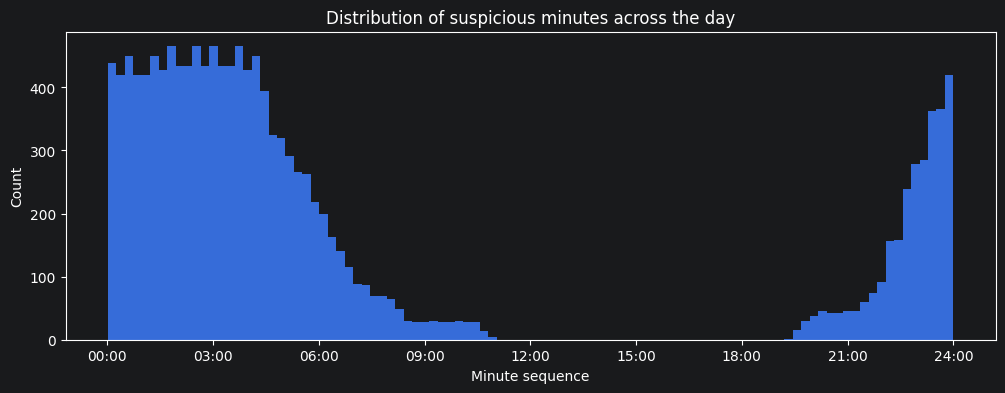

In [50]:
suspicious_minutes = (
    minute_metrics_06[
        minute_metrics_06["is_suspicious"] == True
    ]["minute_sequence"]
)

plt.figure(figsize=(12, 4))
plt.hist(suspicious_minutes, bins=100)
plt.xlabel("Minute sequence")
plt.ylabel("Count")
plt.title("Distribution of suspicious minutes across the day")
plt.xticks(
    ticks=[0, 180, 360, 540, 720, 900, 1080, 1260, 1440],
    labels=["00:00", "03:00", "06:00", "09:00", "12:00", "15:00", "18:00", "21:00", "24:00"],
)
plt.show()

In [51]:
suspicious_participants = minute_metrics_06[minute_metrics_06["is_suspicious"] == True]["ID"].nunique()
total_participants = minute_metrics_06["ID"].nunique()

print(f"Participants with at least one suspicious minute: "
      f"{suspicious_participants} of {total_participants} "
      f"({100 * suspicious_participants / total_participants:.1f}%)")

Participants with at least one suspicious minute: 25 of 2011 (1.2%)


In [52]:
# Drop suspicious minutes from the minute-level dataset to avoid skewing the harmonic regression

suspicious_ids = minute_metrics_06[minute_metrics_06["is_suspicious"] == True]["ID"].unique()
minute_metrics_06 = minute_metrics_06[~minute_metrics_06["ID"].isin(suspicious_ids)]

print(f"Removed {len(suspicious_ids)} participants with suspicious flags.")
print(f"Remaining participants: {minute_metrics_06['ID'].nunique():,}")

Removed 25 participants with suspicious flags.
Remaining participants: 1,986


### Explore non_wear minutes distribution across the day

In [53]:
fully_non_wear_days = (
    minute_metrics_06
    .groupby(["ID", "study_day"])
    .apply(lambda day: (day["is_non_wear"] == True).all())
)

fully_non_wear_days = fully_non_wear_days[fully_non_wear_days]
print(f"Participant-days where entire day is non-wear: {len(fully_non_wear_days)}")
print(f"Participants affected: {fully_non_wear_days.index.get_level_values('ID').nunique()}")


Participant-days where entire day is non-wear: 193
Participants affected: 113


In [54]:
# Drop fully non wear days from the minute-level dataset to avoid skewing the harmonic regression
fully_non_wear_days = fully_non_wear_days[fully_non_wear_days]

minute_metrics_06 = minute_metrics_06[
    ~minute_metrics_06.set_index(["ID", "study_day"]).index.isin(fully_non_wear_days.index)
].reset_index(drop=True)

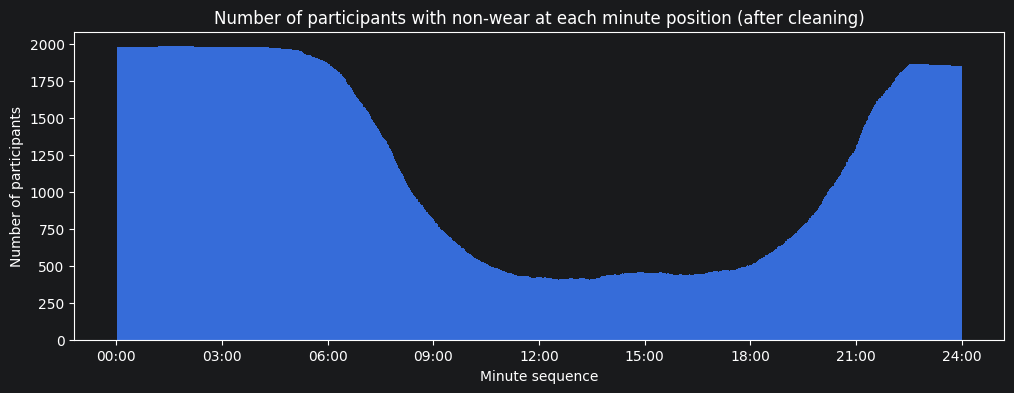

In [55]:
# non wear time after dropping fully non wear days
non_wear_per_minute = (
    minute_metrics_06[minute_metrics_06["is_non_wear"] == True]
    .groupby("minute_sequence")["ID"]
    .nunique()
)

plt.figure(figsize=(12, 4))
plt.bar(non_wear_per_minute.index, non_wear_per_minute.values, width=1)
plt.xlabel("Minute sequence")
plt.ylabel("Number of participants")
plt.title("Number of participants with non-wear at each minute position (after cleaning)")
plt.xticks(
    ticks=[0, 180, 360, 540, 720, 900, 1080, 1260, 1440],
    labels=["00:00", "03:00", "06:00", "09:00", "12:00", "15:00", "18:00", "21:00", "24:00"],
)
plt.show()

### Drop days with less than 10 hours of wear and 24 hours of wear time to ensure stable harmonic regression fits

In [57]:
wear_time_per_day = (
    minute_metrics_06
    .groupby(["ID", "study_day"])["is_non_wear"]
    .apply(lambda x: (x == False).sum() / 60)
    .reset_index()
    .rename(columns={"is_non_wear": "wear_hours"})
)

invalid_days = wear_time_per_day[
    (wear_time_per_day["wear_hours"] == 24) |
    (wear_time_per_day["wear_hours"] < 10)
][["ID", "study_day"]]

minute_metrics_06 = minute_metrics_06[
    ~minute_metrics_06.set_index(["ID", "study_day"]).index.isin(
        invalid_days.set_index(["ID", "study_day"]).index
    )
].reset_index(drop=True)

print(f"Dropped {len(invalid_days):,} days.")
print(f"Remaining participants: {minute_metrics_06['ID'].nunique():,}")

Dropped 312 days.
Remaining participants: 1,979


### Drop participants with fewer than 4 valid days to ensure stable harmonic regression fits

In [58]:
days_per_participant = (
    minute_metrics_06
    .groupby("ID")["study_day"]
    .nunique()
)

valid_participants = days_per_participant[days_per_participant >= 4].index

participants_before = minute_metrics_06["ID"].nunique()
minute_metrics_06 = minute_metrics_06[minute_metrics_06["ID"].isin(valid_participants)].reset_index(drop=True)
participants_after = minute_metrics_06["ID"].nunique()

print(f"Dropped {participants_before - participants_after:,} participants with fewer than 4 valid days.")
print(f"Remaining participants: {participants_after:,}")

Dropped 75 participants with fewer than 4 valid days.
Remaining participants: 1,904
